# DATA7901 — Full Pipeline Walkthrough

Complete step-by-step walkthrough for report and presentation.

| Section | Content |
|---|---|
| 1 | Dataset overview & class imbalance |
| 2 | Image modality — ResNet-18 |
| 3 | Spectral modality — 1D-CNN |
| 4 | Tabular modality — XGBoost |
| 5 | Training process |
| 6 | Late fusion — all three combined |
| 7 | Embedding visualisations (t-SNE) |
| 8 | Performance, hyperparameter search, interpretability |

All figures saved to `notebooks/figures/`. Assumes all checkpoints present.

In [1]:
import sys, pickle, warnings
sys.path.insert(0, '..')
warnings.filterwarnings('ignore')
from pathlib import Path

import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.nn.functional as F
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from PIL import Image
import torchvision.transforms as T
import torchvision.transforms.functional as TF
from sklearn.manifold import TSNE
from sklearn.metrics import f1_score
from sklearn.preprocessing import StandardScaler
from torch.utils.data import DataLoader, TensorDataset
from tqdm.auto import tqdm

from src.datasets.spectral import load_spectrum, WAVE_MIN, WAVE_MAX, WAVE_STEP, N_BINS
from src.datasets.image import get_val_transform, get_train_transform
from src.models.image import ImageClassifier
from src.models.spectral import SpectralClassifier
from src.models.fusion import LateFusionModel
from src.data.rename import apply_renames
from src.data.labels import make_labels
from src.data.features import engineer_features, handle_missing, get_feature_cols
from src.utils.io import get_device, load_checkpoint

LABEL_NAMES = ['elliptical', 'spiral', 'merger']
LABEL_MAP   = {'elliptical': 0, 'spiral': 1, 'merger': 2}
COLORS      = ['#4878D0', '#EE854A', '#D65F5F']
IMG_DIR     = Path('../input/images')
SPEC_DIR    = Path('../input/spectra')
TABLES      = Path('../input/tables')
FIG_DIR     = Path('figures'); FIG_DIR.mkdir(exist_ok=True)

device = get_device()
print(f'Device: {device}')

def load_pkl(path):
    with open(path, 'rb') as f:
        return pickle.load(f)

plt.rcParams.update({'figure.dpi': 120, 'font.size': 9})

Device: cuda


In [2]:
# ── Load full CSV and compute features (needed for tabular + fusion) ──────
# Takes ~30 seconds
print('Loading main CSV and computing features (~30s)...')
df_main = pd.read_csv(TABLES / 'dr19.csv', low_memory=False, on_bad_lines='skip')
df_main = apply_renames(df_main)
df_main = make_labels(df_main)
df_main = handle_missing(df_main)
df_main = engineer_features(df_main)
feature_cols = get_feature_cols(df_main)
print(f'Ready: {len(feature_cols)} features, {len(df_main):,} labeled rows.')

Loading main CSV and computing features (~30s)...
Labeled galaxies: 214,383 / 292,765 filtered rows  (spec_z <= 0.1)
  elliptical  : 108,296  (50.5%)
  spiral      : 104,613  (48.8%)
  merger      :  1,474  (0.7%)
Ready: 47 features, 214,383 labeled rows.


In [3]:
# ── Load all four models ──────────────────────────────────────────────────
# Image: ResNet-18 config C (best: dropout=0.3, pretrained ImageNet, lr=1e-4)
img_model = ImageClassifier(pretrained=False, dropout=0.3).to(device)
load_checkpoint(img_model, Path('../checkpoints/image/resnet18_configC_best.pth'), device)
img_model.eval()

# Spectral: 1D-CNN config A (best: 32 base filters, no dropout, lr=1e-4)
spec_model = SpectralClassifier(base_filters=32, dropout=0.0).to(device)
load_checkpoint(spec_model, Path('../checkpoints/spectral/cnn1d_best.pth'), device)
spec_model.eval()

# Fusion: best-encoder checkpoint (ResNet-18 configC + 1D-CNN configA)
fusion_model = LateFusionModel(n_tab_features=len(feature_cols)).to(device)
load_checkpoint(fusion_model, Path('../checkpoints/fusion/late_fusion_bestenc_best.pth'), device)
fusion_model.eval()

# Tabular: XGBoost + fitted StandardScaler (handles scaling internally)
tab_pkg       = load_pkl('../checkpoints/tabular/xgb_model_full.pkl')
tab_pipeline  = tab_pkg['pipeline']
tab_feat_cols = tab_pkg['feature_cols']

print('All models loaded.')
print(f'  ImageClassifier    : ResNet-18 → 512-d encoder → Linear(3)')
print(f'  SpectralClassifier : 1D-CNN   → 128-d encoder → Linear(3)')
print(f'  LateFusionModel    : 705-d concat → Linear(256) → Linear(3)')
print(f'  TabularPipeline    : XGBoost ({len(tab_feat_cols)} features)')

All models loaded.
  ImageClassifier    : ResNet-18 → 512-d encoder → Linear(3)
  SpectralClassifier : 1D-CNN   → 128-d encoder → Linear(3)
  LateFusionModel    : 705-d concat → Linear(256) → Linear(3)
  TabularPipeline    : XGBoost (47 features)


In [4]:
# ── Pick one representative test galaxy per class ─────────────────────────
test_df = pd.read_csv(TABLES / 'split_test.csv')
samples = {}
for label in LABEL_NAMES:
    row = test_df[
        (test_df['label'] == label) &
        test_df['has_image'] & test_df['has_spectrum']
    ].iloc[0]
    samples[label] = row
    print(f'{label:12s}: objid={int(row["objid"])} '
          f'plate={int(row["plate"])} mjd={int(row["spec_mjd"])} fiber={int(row["fiberid"]):04d}')

sample_tab = {}
for label, row in samples.items():
    obj = df_main[df_main['objid'] == int(row['objid'])]
    if len(obj) > 0:
        sample_tab[label] = obj.iloc[0]
    else:
        print(f'WARNING: {label} not found in main data')

def spec_path(row):
    return SPEC_DIR / f"spec-{int(row['plate'])}-{int(row['spec_mjd'])}-{int(row['fiberid']):04d}.fits"

print('\nSample galaxies ready.')

elliptical  : objid=1237667783900266609 plate=2488 mjd=54149 fiber=0338
spiral      : objid=1237657775006286005 plate=1199 mjd=52703 fiber=0509
merger      : objid=1237661966887223422 plate=1437 mjd=53046 fiber=0175

Sample galaxies ready.


---
## Section 1 — Dataset Overview

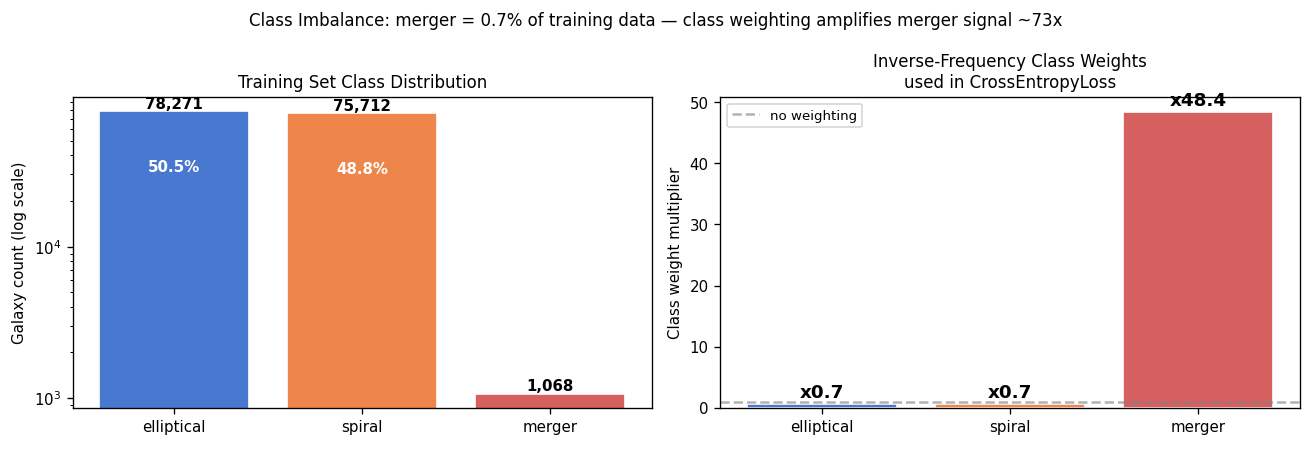

Class counts: elliptical=78,271  spiral=75,712  merger=1,068


In [5]:
# ── 1a. Class distribution & class weights ────────────────────────────────
train_df = pd.read_csv(TABLES / 'split_train_full.csv')
counts = np.array([train_df[train_df['label'] == lb].shape[0] for lb in LABEL_NAMES])
weights = counts.sum() / (3 * counts)

fig, axes = plt.subplots(1, 2, figsize=(11, 4))

bars = axes[0].bar(LABEL_NAMES, counts, color=COLORS, edgecolor='white')
for b, v in zip(bars, counts):
    axes[0].text(b.get_x()+b.get_width()/2, v*1.05, f'{v:,}', ha='center', fontsize=9, fontweight='bold')
axes[0].set_yscale('log')
axes[0].set_ylabel('Galaxy count (log scale)')
axes[0].set_title('Training Set Class Distribution', fontsize=10)
for i, (cnt, total) in enumerate(zip(counts, [counts.sum()]*3)):
    axes[0].text(i, counts[i]*0.4, f'{100*cnt/total:.1f}%', ha='center', fontsize=9, color='white', fontweight='bold')

bars2 = axes[1].bar(LABEL_NAMES, weights, color=COLORS, edgecolor='white')
for b, v in zip(bars2, weights):
    axes[1].text(b.get_x()+b.get_width()/2, v+1, f'x{v:.1f}', ha='center', fontsize=11, fontweight='bold')
axes[1].axhline(1.0, color='gray', lw=1.5, ls='--', alpha=0.6, label='no weighting')
axes[1].set_ylabel('Class weight multiplier')
axes[1].set_title('Inverse-Frequency Class Weights\nused in CrossEntropyLoss', fontsize=10)
axes[1].legend(fontsize=8)

fig.suptitle('Class Imbalance: merger = 0.7% of training data — class weighting amplifies merger signal ~73x', fontsize=10)
fig.tight_layout()
fig.savefig(FIG_DIR / 'fig1b_class_distribution.pdf', bbox_inches='tight')
fig.savefig(FIG_DIR / 'fig1b_class_distribution.png', dpi=150, bbox_inches='tight')
plt.show()
print(f'Class counts: elliptical={counts[0]:,}  spiral={counts[1]:,}  merger={counts[2]:,}')

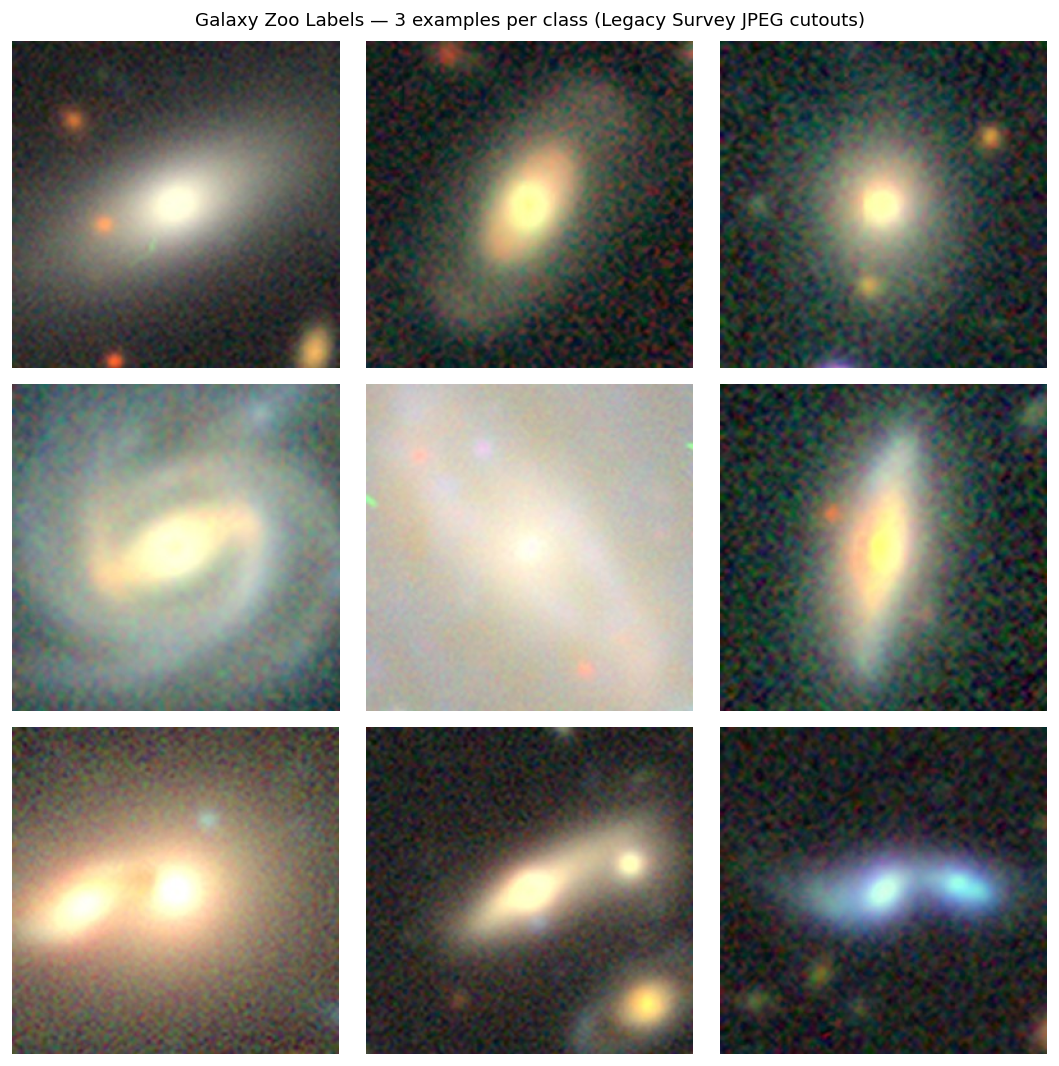

In [6]:
# ── 1b. Sample galaxy mosaic (3 per class) ───────────────────────────────
fig, axes = plt.subplots(3, 3, figsize=(9, 9))
for row_i, label in enumerate(LABEL_NAMES):
    rows = test_df[(test_df['label'] == label) & test_df['has_image']].head(3)
    for col_i, (_, row) in enumerate(rows.iterrows()):
        pil = Image.open(IMG_DIR / f"{int(row['objid'])}.jpeg")
        axes[row_i, col_i].imshow(pil)
        axes[row_i, col_i].axis('off')
        if col_i == 0:
            axes[row_i, col_i].set_ylabel(label, fontsize=11, fontweight='bold',
                                           color=COLORS[row_i], rotation=0, labelpad=60, va='center')
fig.suptitle('Galaxy Zoo Labels — 3 examples per class (Legacy Survey JPEG cutouts)', fontsize=11)
fig.tight_layout()
fig.savefig(FIG_DIR / 'fig0_sample_galaxies.pdf', bbox_inches='tight')
fig.savefig(FIG_DIR / 'fig0_sample_galaxies.png', dpi=150, bbox_inches='tight')
plt.show()

---
## Section 2 — Image Modality: ResNet-18

**Pipeline:**
```
JPEG (native) → resize/crop 224×224 → augment (train) / normalise (val)
             → ResNet-18 encoder (pretrained ImageNet, fc=Identity)
             → 512-d feature vector
             → Dropout(0.3) + Linear(512→3)
             → softmax → class probabilities
```
**Why ResNet-18?** Lightweight, pretrained on ImageNet (edge/texture detectors transfer to galaxies), fast enough for 155k training images. Spatial morphology (spiral arms, bulge shape) is directly visible in 2D images — the strongest single modality.

## 🖼️ Section 2 — Image Modality: ResNet-18 (The "Eyes" of the Model)

### How does a neural network "see" a galaxy?

Think of the **ResNet-18 image encoder as a pair of highly trained eyes** that have looked at millions of natural images (ImageNet: cats, cars, trees…). Through *transfer learning*, we repurpose these pre-built visual skills for galaxy morphology — because low-level image features like edges, curves, and textures are universal.

**The encoding pipeline works in layers of increasing abstraction:**

| Stage | What the network learns | Galaxy example |
|---|---|---|
| `conv1` + `layer1` (early) | Edges, brightness gradients, colour patches | Bright core vs. dark background, dust lanes |
| `layer2` + `layer3` (middle) | Textures, curves, symmetry | Spiral arm curvature, disc vs. bulge structure |
| `layer4` (deep) | Semantic shapes, structural patterns | "Extended disc with clumpy arms" or "smooth round blob" |
| `AdaptiveAvgPool` → 512-d | Compact morphological fingerprint | One activation per learned visual concept |

**Why 512 dimensions?** Each of the 512 numbers in the output vector represents the **strength of one learned visual concept**. The model never explicitly learns "spiral arm" — it discovers which combinations of pixel patterns statistically separate ellipticals from spirals from mergers.

> 🔬 **Analogy:** A radiologist reading an X-ray doesn't consciously run through a checklist — they have built an *intuition for patterns* from thousands of prior cases. ResNet-18 works the same way, but for galaxies. The transfer from natural images works because **edges and curves look the same whether they appear in a cat photo or a galaxy JPEG**.

**Backpropagation in one sentence:** During training, the loss (how wrong the prediction was) flows *backward* through all 512 features simultaneously, nudging each filter weight slightly so the next prediction is a little better. After ~150k galaxy examples, the filters have self-organised into a detector bank optimised for galaxy morphology.

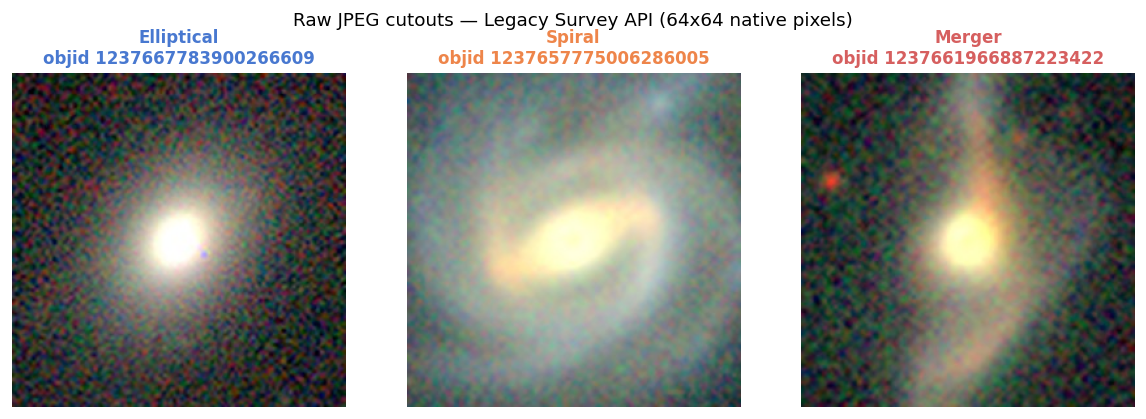

In [42]:
# ── 2a. Raw galaxy images ─────────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(10, 3.5))
for ax, (label, c) in zip(axes, zip(LABEL_NAMES, COLORS)):
    row = samples[label]
    img = Image.open(IMG_DIR / f"{int(row['objid'])}.jpeg")
    ax.imshow(img)
    ax.set_title(f'{label.capitalize()}\nobjid {int(row["objid"])}', fontsize=10, color=c, fontweight='bold')
    ax.axis('off')
fig.suptitle('Raw JPEG cutouts — Legacy Survey API (64x64 native pixels)', fontsize=11)
fig.tight_layout()
fig.savefig(FIG_DIR / 'walk_raw_images.svg', bbox_inches='tight', transparent=True)
plt.show()

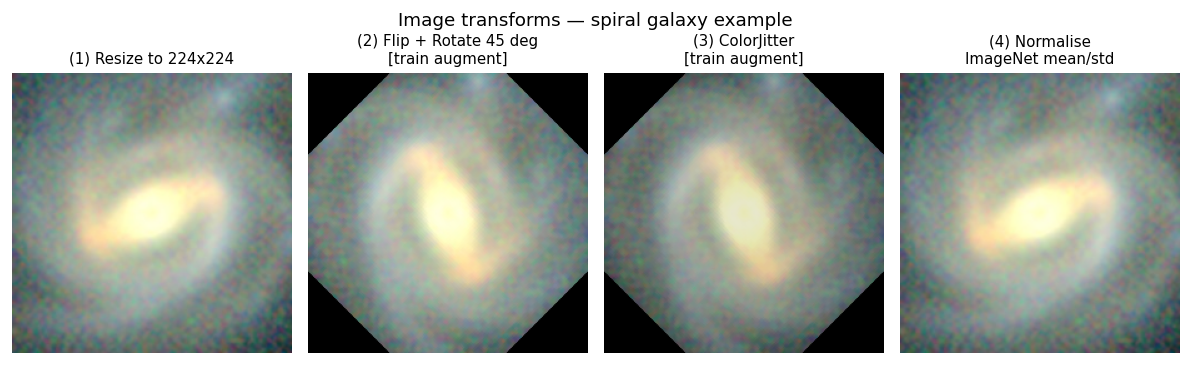

In [49]:
# ── 2b. Transform pipeline (training augmentation) ────────────────────────
row = samples['spiral']
raw_pil = Image.open(IMG_DIR / f"{int(row['objid'])}.jpeg").convert('RGB')
raw_224 = raw_pil.resize((224, 224), Image.BILINEAR)

step1 = raw_224
step2 = TF.hflip(TF.rotate(raw_224, 45))
step3 = T.ColorJitter(brightness=0.3, contrast=0.3, saturation=0.2)(step2)
mean  = np.array([0.485, 0.456, 0.406])
std   = np.array([0.229, 0.224, 0.225])
norm_t = get_val_transform()(raw_pil)
step4_disp = np.clip(norm_t.permute(1, 2, 0).numpy() * std + mean, 0, 1)

fig, axes = plt.subplots(1, 4, figsize=(10, 3.2))
for ax, (title, img) in zip(axes, [
    ('(1) Resize to 224x224', np.array(step1)),
    ('(2) Flip + Rotate 45 deg\n[train augment]', np.array(step2)),
    ('(3) ColorJitter\n[train augment]', np.array(step3)),
    ('(4) Normalise\nImageNet mean/std', step4_disp),
]):
    ax.imshow(img)
    ax.set_title(title, fontsize=9)
    ax.axis('off')
fig.suptitle('Image transforms — spiral galaxy example', fontsize=11)
fig.tight_layout()
fig.savefig(FIG_DIR / 'walk_img_transforms.pdf', bbox_inches='tight', transparent=True)
fig.savefig(FIG_DIR / 'walk_img_transforms.svg', bbox_inches='tight', transparent=True)
fig.savefig(FIG_DIR / 'walk_img_transforms.png', dpi=200, bbox_inches='tight', transparent=True)
plt.show()

In [9]:
# ── 2c. Tensor shape trace through ResNet-18 ──────────────────────────────
print('=' * 55)
print('ResNet-18 forward pass — tensor shapes')
print('=' * 55)
row = samples['spiral']
pil = Image.open(IMG_DIR / f"{int(row['objid'])}.jpeg").convert('RGB')
print(f'  Input PIL image  : {pil.size[0]} x {pil.size[1]} pixels (JPEG)')
t0 = get_val_transform()(pil)
print(f'  After transform  : {tuple(t0.shape)}  (C x H x W)')
t1 = t0.unsqueeze(0).to(device)
print(f'  + batch dim      : {tuple(t1.shape)}  (B x C x H x W)')
with torch.no_grad():
    feat = img_model.encoder(t1)
print(f'  ResNet-18 encoder: {tuple(feat.shape)}  (B x 512)  — global avg pool of last conv')
with torch.no_grad():
    logits = img_model(t1)
print(f'  Linear head      : {tuple(logits.shape)}  (B x 3)   — raw scores per class')
probs = F.softmax(logits, dim=1)
print(f'  Softmax          : {tuple(probs.shape)}  (B x 3)   — probabilities sum to 1')
print(f'  Prediction       : {LABEL_NAMES[probs.argmax().item()]} '
      f'(P={probs.max().item():.3f})')
print('=' * 55)

ResNet-18 forward pass — tensor shapes
  Input PIL image  : 256 x 256 pixels (JPEG)
  After transform  : (3, 224, 224)  (C x H x W)
  + batch dim      : (1, 3, 224, 224)  (B x C x H x W)
  ResNet-18 encoder: (1, 512)  (B x 512)  — global avg pool of last conv
  Linear head      : (1, 3)  (B x 3)   — raw scores per class
  Softmax          : (1, 3)  (B x 3)   — probabilities sum to 1
  Prediction       : spiral (P=0.999)


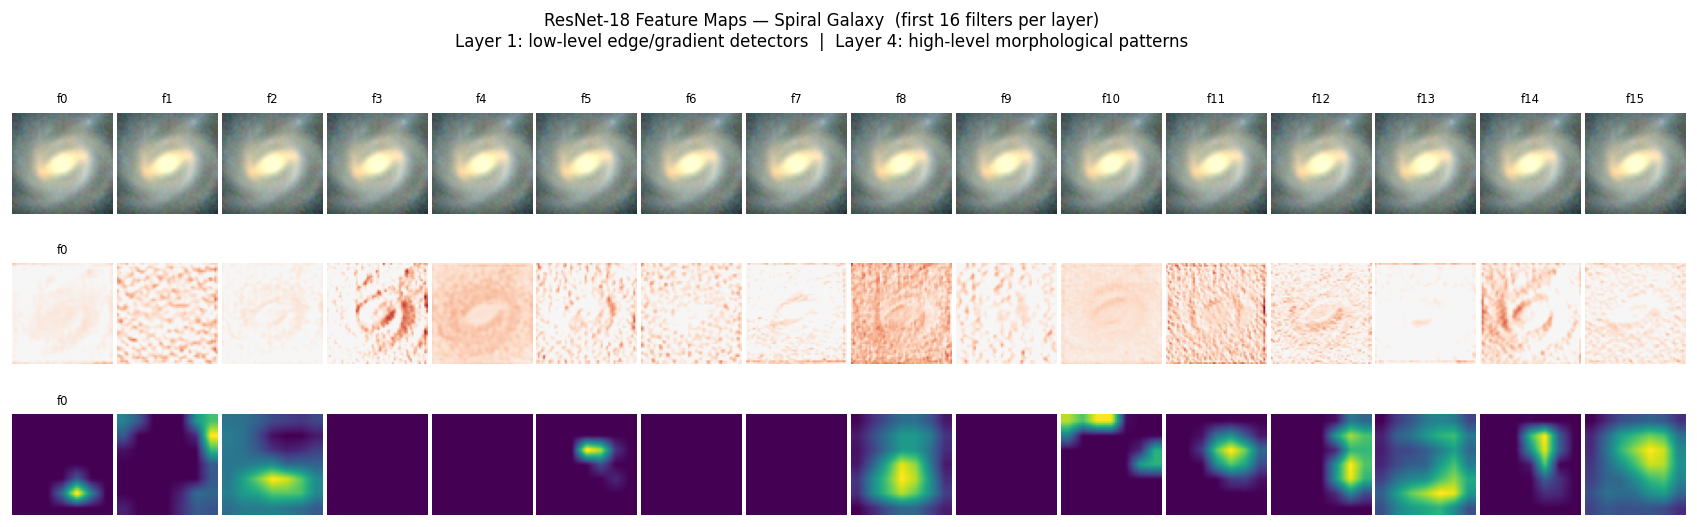

Observation: Layer 1 filters resemble edge detectors (similar to Gabor wavelets).
             Layer 4 filters show localized semantic activations — the network has
             learned to respond to specific structural regions of the galaxy.


In [50]:
# 🔬 2c2. ResNet-18 intermediate feature maps — early layers (edges) vs deep layers (shapes)
# ─────────────────────────────────────────────────────────────────────────────────────────
# Register forward hooks on layer1 (64 ch, 56×56) and layer4 (512 ch, 7×7).
# Visualise the first 16 filter responses for the spiral sample.
# Layer1 captures low-level edges/gradients; layer4 captures high-level morphological shapes.

feat_maps = {}

def _make_hook(name):
    def hook(module, inp, out):
        feat_maps[name] = out.detach().cpu()
    return hook

h1 = img_model.encoder.layer1.register_forward_hook(_make_hook('layer1'))
h4 = img_model.encoder.layer4.register_forward_hook(_make_hook('layer4'))

row_s = samples['spiral']
pil_s = Image.open(IMG_DIR / f"{int(row_s['objid'])}.jpeg").convert('RGB')
t_s   = get_val_transform()(pil_s).unsqueeze(0).to(device)

with torch.no_grad():
    _ = img_model(t_s)

h1.remove(); h4.remove()

# ── Plot: 3 rows × 16 cols ────────────────────────────────────────────────────────────────
fig, axes = plt.subplots(3, 16, figsize=(18, 4.8),
                         gridspec_kw=dict(hspace=0.06, wspace=0.04))

# Row 0: original image (resized to 56×56 to match layer1 spatial resolution)
img_56 = np.array(pil_s.resize((56, 56)))
for j in range(16):
    axes[0, j].imshow(img_56)
    axes[0, j].axis('off')
    if j == 0:
        axes[0, j].set_title('f0', fontsize=7)
axes[0, 0].set_ylabel('Input\n(56×56)', rotation=0, ha='right', va='center', fontsize=8, labelpad=48)

# Row 1: layer1 (64 channels, 56×56) — first 16 channels
l1 = feat_maps['layer1'][0].numpy()   # (64, 56, 56)
vl1 = float(np.abs(l1[:16]).max()) + 1e-8
for j in range(16):
    axes[1, j].imshow(l1[j], cmap='RdBu_r', vmin=-vl1, vmax=vl1)
    axes[1, j].axis('off')
    if j == 0:
        axes[1, j].set_title('f0', fontsize=7)
axes[1, 0].set_ylabel('Layer 1\n(edges &\ncolour detectors)', rotation=0,
                       ha='right', va='center', fontsize=8, labelpad=48)

# Row 2: layer4 (512 channels, 7×7) — first 16 channels, upsampled for visibility
l4    = feat_maps['layer4'][0].numpy()   # (512, 7, 7)
l4_up = F.interpolate(torch.tensor(l4).unsqueeze(0), size=56, mode='bilinear',
                       align_corners=False)[0].numpy()
vl4   = float(np.abs(l4_up[:16]).max()) + 1e-8
for j in range(16):
    axes[2, j].imshow(l4_up[j], cmap='viridis')
    axes[2, j].axis('off')
    if j == 0:
        axes[2, j].set_title('f0', fontsize=7)
axes[2, 0].set_ylabel('Layer 4\n(semantic shape\ndetectors)', rotation=0,
                       ha='right', va='center', fontsize=8, labelpad=48)

# Column labels
for j in range(1, 16):
    axes[0, j].set_title(f'f{j}', fontsize=7)

fig.suptitle("ResNet-18 Feature Maps — Spiral Galaxy  (first 16 filters per layer)\n"
             "Layer 1: low-level edge/gradient detectors  |  Layer 4: high-level morphological patterns",
             fontsize=10, y=1.02)

fig.savefig(FIG_DIR / 'walk_resnet_feature_maps.pdf', bbox_inches='tight', transparent=True)
fig.savefig(FIG_DIR / 'walk_resnet_feature_maps.png', dpi=150, bbox_inches='tight', transparent=True)
fig.savefig(FIG_DIR / 'walk_resnet_feature_maps.svg', bbox_inches='tight', transparent=True)
plt.show()

print('Observation: Layer 1 filters resemble edge detectors (similar to Gabor wavelets).')
print('             Layer 4 filters show localized semantic activations — the network has')
print('             learned to respond to specific structural regions of the galaxy.')


In [11]:
# ── 2d. Encode all three sample galaxies ──────────────────────────────────
val_t = get_val_transform()
img_results = {}
for label, row in samples.items():
    pil   = Image.open(IMG_DIR / f"{int(row['objid'])}.jpeg").convert('RGB')
    t     = val_t(pil).unsqueeze(0).to(device)
    with torch.no_grad():
        feat   = img_model.encoder(t).cpu().numpy()[0]
        probs  = F.softmax(img_model(t), dim=1).cpu().numpy()[0]
    img_results[label] = {'probs': probs, 'feat': feat, 'pred': LABEL_NAMES[probs.argmax()]}

print('ResNet-18 predictions:')
for label, r in img_results.items():
    ok = 'CORRECT' if r['pred'] == label else f'WRONG -> {r["pred"]}'
    print(f'  {label:12s}: [{ok}]  P(ell)={r["probs"][0]:.3f}  P(spi)={r["probs"][1]:.3f}  P(mer)={r["probs"][2]:.3f}')

ResNet-18 predictions:
  elliptical  : [CORRECT]  P(ell)=1.000  P(spi)=0.000  P(mer)=0.000
  spiral      : [CORRECT]  P(ell)=0.000  P(spi)=0.999  P(mer)=0.001
  merger      : [CORRECT]  P(ell)=0.001  P(spi)=0.397  P(mer)=0.602


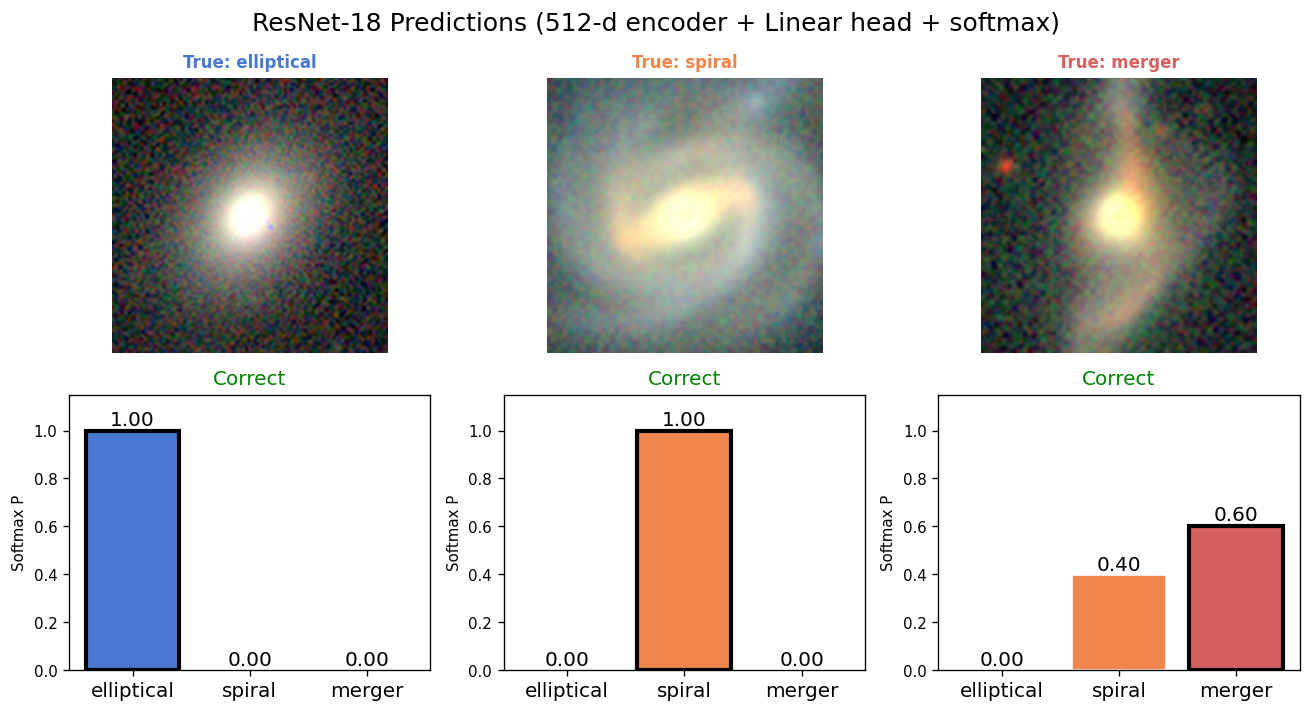

In [57]:
# ── 2e. Image + prediction bar charts ────────────────────────────────────
fig = plt.figure(figsize=(11, 6))
for col, (label, c) in enumerate(zip(LABEL_NAMES, COLORS)):
    row = samples[label]
    res = img_results[label]
    pil = Image.open(IMG_DIR / f"{int(row['objid'])}.jpeg").convert('RGB')

    ax_img = fig.add_subplot(2, 3, col + 1)
    ax_img.imshow(np.array(pil.resize((224, 224))))
    ax_img.set_title(f'True: {label}', fontsize=10, fontweight='bold', color=c)
    ax_img.axis('off')

    ax_bar = fig.add_subplot(2, 3, col + 4)
    bars = ax_bar.bar(LABEL_NAMES, res['probs'], color=COLORS, edgecolor='white')
    bars[res['probs'].argmax()].set_edgecolor('black')
    bars[res['probs'].argmax()].set_linewidth(2.5)
    for b, v in zip(bars, res['probs']):
        ax_bar.text(b.get_x()+b.get_width()/2, v+0.02, f'{v:.2f}', ha='center', fontsize=12)
    ax_bar.set_ylim(0, 1.15)
    ax_bar.set_ylabel('Softmax P')
    ok = 'Correct' if res['pred'] == label else f'Wrong: {res["pred"]}'
    ax_bar.set_title(ok, fontsize=12, color='green' if res['pred'] == label else 'red')
    ax_bar.tick_params(axis='x', labelsize=12)

fig.suptitle('ResNet-18 Predictions (512-d encoder + Linear head + softmax)', fontsize=15)
fig.tight_layout()
fig.savefig(FIG_DIR / 'walk_img_predictions.pdf', bbox_inches='tight', transparent=True)
fig.savefig(FIG_DIR / 'walk_img_predictions.png', dpi=150, bbox_inches='tight', transparent=True)
fig.savefig(FIG_DIR / 'walk_img_predictions.svg', bbox_inches='tight', transparent=True)
plt.show()

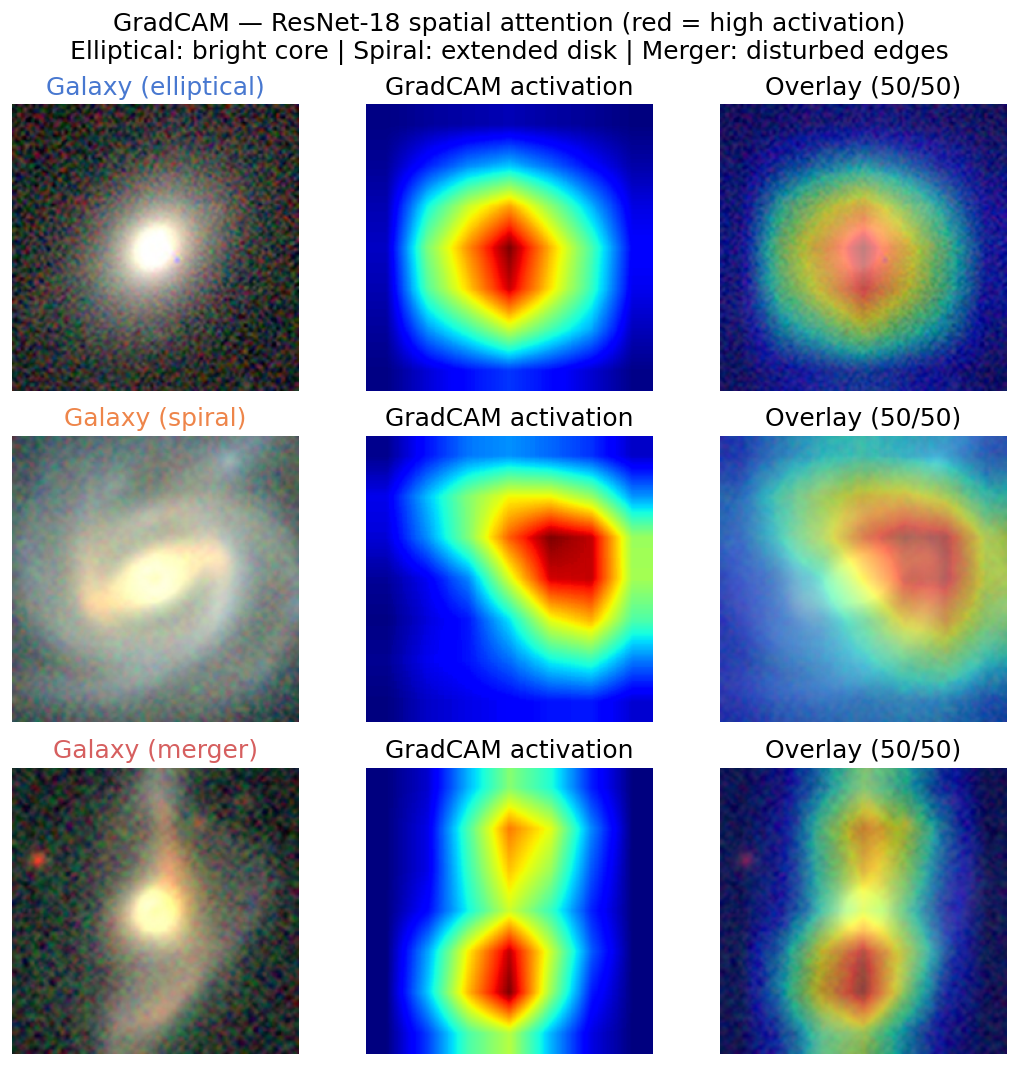

In [54]:
# ── 2f. GradCAM — what spatial regions drive the prediction ──────────────
class GradCAM:
    """Class activation maps via gradient weighting on ResNet-18 layer4[-1]."""
    def __init__(self, model):
        self.model = model
        self.grads = self.acts = None
        layer = model.encoder.layer4[-1]
        layer.register_forward_hook(lambda m, i, o: setattr(self, 'acts', o.detach()))
        layer.register_backward_hook(lambda m, gi, go: setattr(self, 'grads', go[0].detach()))

    def __call__(self, tensor, class_idx):
        t = tensor.unsqueeze(0); t.requires_grad_(True)
        self.model.eval()
        logits = self.model(t)
        self.model.zero_grad()
        logits[0, class_idx].backward()
        weights = self.grads.mean(dim=(2, 3), keepdim=True)
        cam = F.relu((weights * self.acts).sum(1).squeeze())
        cam = cam.cpu().numpy()
        return cam / max(cam.max(), 1e-8)

cam_fn = GradCAM(img_model)
val_t  = get_val_transform()

fig, axes = plt.subplots(3, 3, figsize=(9, 9))
for row_i, (label, c) in enumerate(zip(LABEL_NAMES, COLORS)):
    row = samples[label]
    pil = Image.open(IMG_DIR / f"{int(row['objid'])}.jpeg").convert('RGB')
    t   = val_t(pil).to(device)
    cam = cam_fn(t, LABEL_MAP[label])

    img_np   = np.array(pil.resize((224, 224))).astype(float) / 255.0
    cam_pil  = Image.fromarray((cam * 255).astype(np.uint8)).resize((224, 224), Image.BILINEAR)
    cam_np   = np.array(cam_pil) / 255.0
    cmap_rgb = plt.cm.jet(cam_np)[..., :3]
    overlay  = np.clip(0.5 * img_np + 0.5 * cmap_rgb, 0, 1)

    axes[row_i, 0].imshow(img_np);    axes[row_i, 0].set_title(f'Galaxy ({label})', fontsize=15, color=c)
    axes[row_i, 1].imshow(cam_np, cmap='jet'); axes[row_i, 1].set_title('GradCAM activation', fontsize=15)
    axes[row_i, 2].imshow(overlay);   axes[row_i, 2].set_title('Overlay (50/50)', fontsize=15)
    for ax in axes[row_i]: ax.axis('off')

fig.suptitle('GradCAM — ResNet-18 spatial attention (red = high activation)\nElliptical: bright core | Spiral: extended disk | Merger: disturbed edges', fontsize=15)
fig.tight_layout()
fig.savefig(FIG_DIR / 'fig7_gradcam.pdf', bbox_inches='tight', transparent=True)
fig.savefig(FIG_DIR / 'fig7_gradcam.png', dpi=150, bbox_inches='tight', transparent=True)
fig.savefig(FIG_DIR / 'fig7_gradcam.svg', bbox_inches='tight', transparent=True)
plt.show()

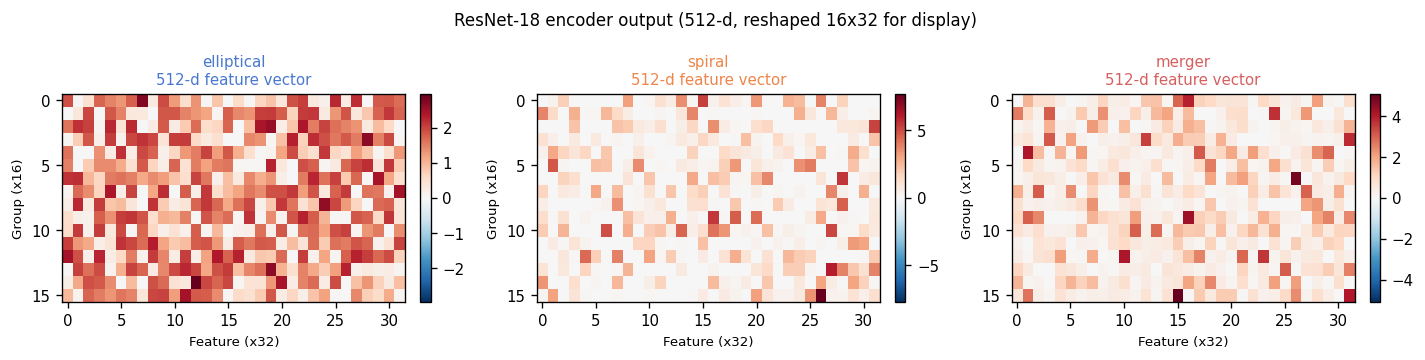

In [14]:
# ── 2g. 512-d encoder output (reshaped to 16x32 heatmap) ─────────────────
fig, axes = plt.subplots(1, 3, figsize=(12, 3))
for ax, (label, c) in zip(axes, zip(LABEL_NAMES, COLORS)):
    feat = img_results[label]['feat'].reshape(16, 32)
    vmax = np.abs(feat).max()
    im   = ax.imshow(feat, aspect='auto', cmap='RdBu_r', vmin=-vmax, vmax=vmax)
    ax.set_title(f'{label}\n512-d feature vector', fontsize=9, color=c)
    ax.set_xlabel('Feature (x32)', fontsize=8); ax.set_ylabel('Group (x16)', fontsize=8)
    plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
fig.suptitle('ResNet-18 encoder output (512-d, reshaped 16x32 for display)', fontsize=10)
fig.tight_layout()

fig.savefig(FIG_DIR / 'walk_img_features.pdf', bbox_inches='tight')
plt.show()

---
## Section 3 — Spectral Modality: 1D-CNN

**Pipeline:**
```
FITS file → read log-lambda grid → resample to 3800-9200 A (2700 bins, 2 A/px)
          → clip outliers at +/-5 sigma → divide by |median|
          → (1, 2700) tensor
          → Conv1d(1,32,k=15) -> BN -> ReLU -> MaxPool4  (32 x 675)
          -> Conv1d(32,64,k=9) -> BN -> ReLU -> MaxPool4 (64 x 168)
          -> Conv1d(64,128,k=5)-> BN -> ReLU -> MaxPool4 (128 x 42)
          -> GlobalAvgPool -> 128-d
          -> Linear(128->3) -> softmax
```
**Why spectra?** Each spectrum encodes the galaxy's stellar population: Halpha emission (6563 A) signals star-forming spirals; Ca H&K absorption (3933/3968 A) and the Dn4000 break signal old stellar populations in ellipticals. Spectra classify *physical* type rather than *visual shape* — useful for the fusion model.

## 🌈 Section 3 — Spectral Modality: 1D-CNN (The "DNA Test" of the Model)

### What does a galaxy's spectrum tell us?

If images are the galaxy's *appearance*, its spectrum is its **chemical fingerprint**. By dispersing light through a prism, we record how much light is emitted at each wavelength — revealing the galaxy's physical nature through a pattern of emission and absorption lines:

| Spectral feature | Wavelength | What it reveals |
|---|---|---|
| **Hα emission** | 6563 Å | Active star formation — hot young blue stars ionise surrounding hydrogen gas |
| **[OII] emission** | 3726–3729 Å | Ionised gas in star-forming regions; proxy for star formation rate |
| **Ca H&K absorption** | 3933/3968 Å | Old stellar populations — no new stars being born (passive galaxy) |
| **Dn4000 break** | ~4000 Å | Amplitude of the jump at 4000 Å tracks the **age** of the stellar population |
| **[OIII] emission** | 4959/5007 Å | AGN or strong star-formation indicator |

### The 1D-CNN as a "DNA Reader"

> 🧬 **Analogy:** Just as a DNA sequencer looks for specific patterns in a long string of base pairs (ATCG…), the 1D-CNN slides small *convolutional filters* across the 2700-bin spectrum (3800–9200 Å at 2 Å/pixel) searching for characteristic patterns. It doesn't explicitly know about Hα — but it *learns* that "a bump at bin ~1381 (≈6563 Å)" reliably predicts the spiral/star-forming class, because that's what the training data shows.

### Why does the spectral model underperform on morphology?

The spectrum captures **physical type** (star-forming vs. passive) more directly than **visual shape** (spiral arms, bulge geometry). A passive lenticular galaxy and an elliptical can look physically identical in spectra despite having very different images. This is why:

- Spectral model morphology macro-F1: **0.563**
- Spectral model *physical* classification macro-F1: **0.935** (+0.37)

This gap motivates **late fusion** — by combining the spectrum (physical) with the image (visual) and photometry (structural), the fusion model accesses complementary information that no single modality captures alone.

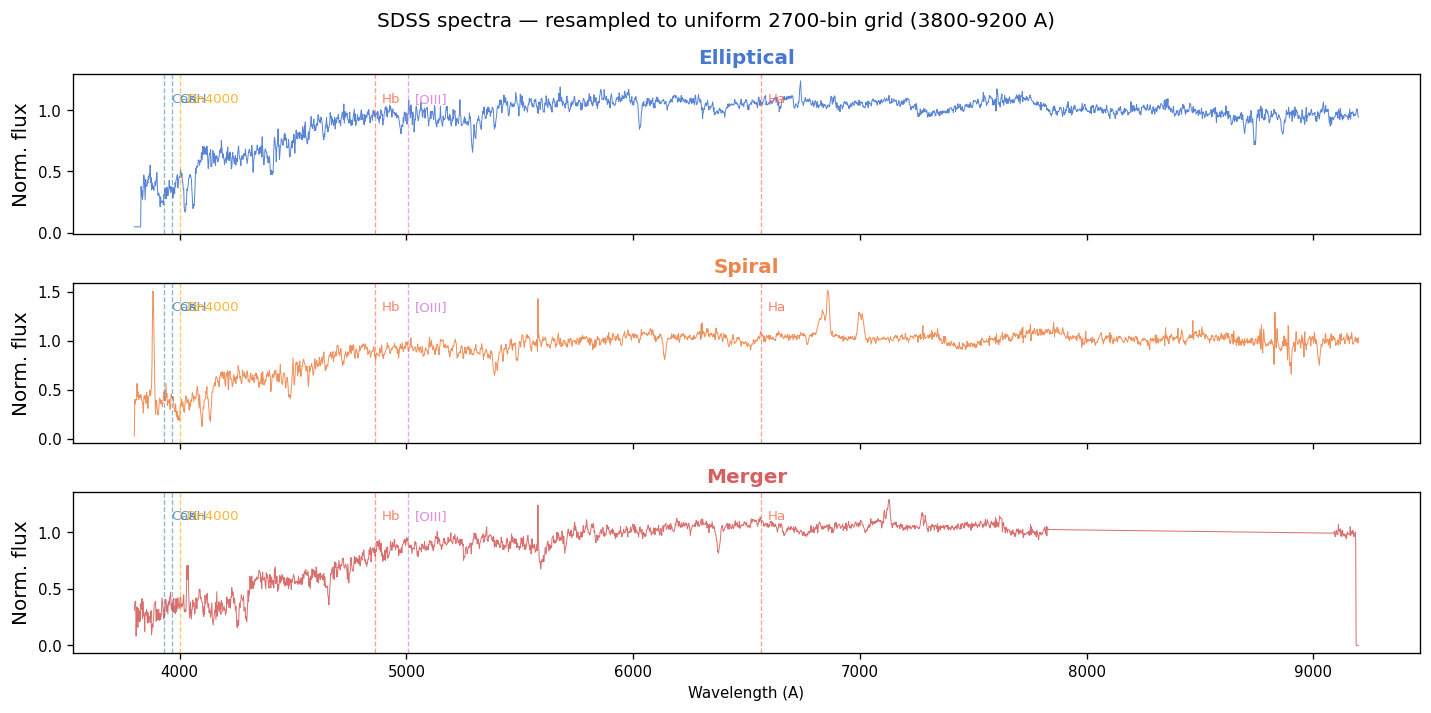

In [74]:
# ── 3a. Raw spectra (3 classes, key lines marked) ─────────────────────────
wave_grid = np.arange(WAVE_MIN, WAVE_MAX, WAVE_STEP)
SPECTRAL_LINES = {
    'Ha':     (6563, 'tomato'),
    'Hb':     (4861, 'tomato'),
    '[OIII]': (5007, 'orchid'),
    'CaK':    (3933, 'steelblue'),
    'CaH':    (3968, 'steelblue'),
    'Dn4000': (4000, 'orange'),
}

fig, axes = plt.subplots(3, 1, figsize=(12, 6), sharex=True)
for ax, (label, c) in zip(axes, zip(LABEL_NAMES, COLORS)):
    row  = samples[label]
    flux = load_spectrum(spec_path(row))
    ax.plot(wave_grid, flux, lw=0.6, color=c, alpha=0.9)
    ax.set_ylabel('Norm. flux', fontsize=12)
    ax.set_title(f'{label.capitalize()}', fontsize=12, color=c, fontweight='bold')
    ymax = ax.get_ylim()[1]
    for name, (wl, lc) in SPECTRAL_LINES.items():
        if WAVE_MIN < wl < WAVE_MAX:
            ax.axvline(wl, color=lc, lw=0.8, alpha=0.6, ls='--')
            ax.text(wl + 30, ymax * 0.82, name, fontsize=8, color=lc, alpha=0.8)
axes[-1].set_xlabel('Wavelength (A)', fontsize=9)
fig.suptitle('SDSS spectra — resampled to uniform 2700-bin grid (3800-9200 A)', fontsize=12)
fig.tight_layout()
fig.savefig(FIG_DIR / 'walk_spectra_raw.pdf', bbox_inches='tight')
fig.savefig(FIG_DIR / 'walk_spectra_raw.png', dpi=150, bbox_inches='tight', transparent=True)
fig.savefig(FIG_DIR / 'walk_spectra_raw.svg', bbox_inches='tight', transparent=True)
plt.show()

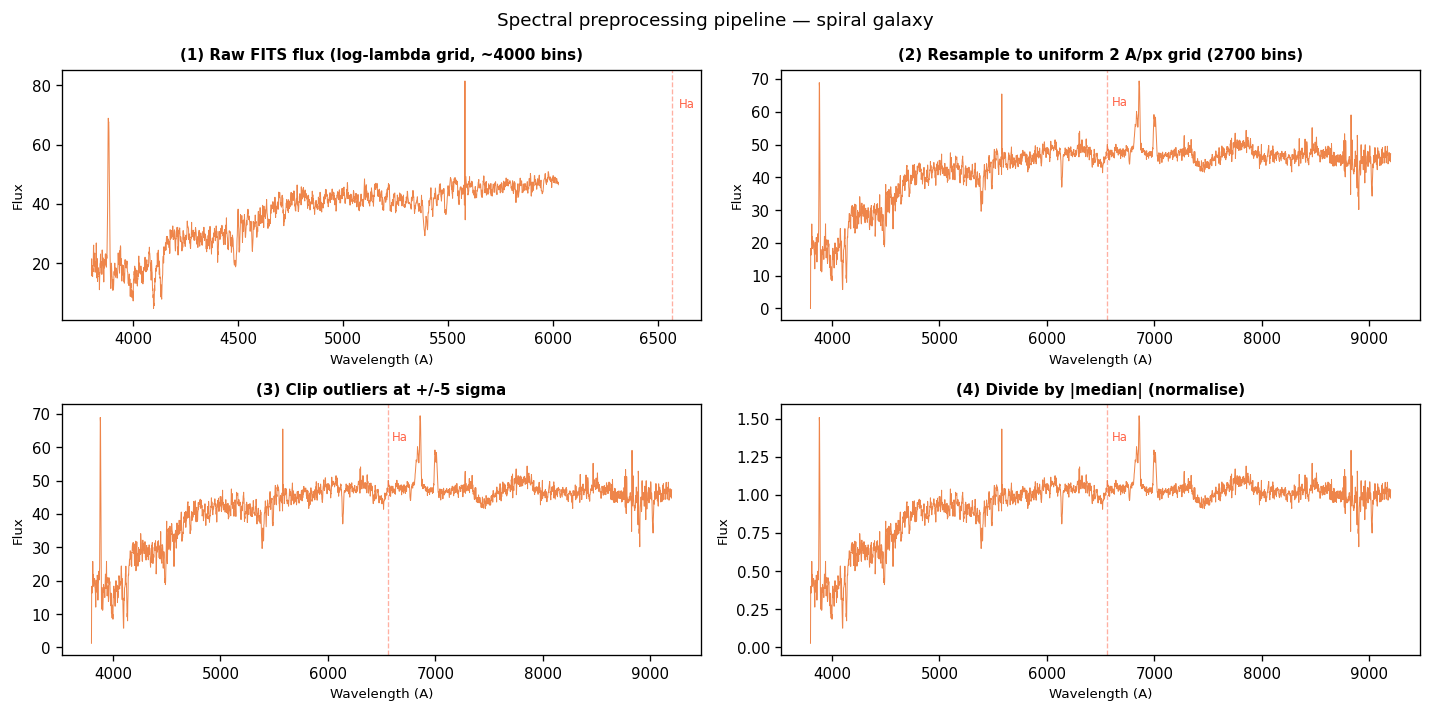

In [16]:
# ── 3b. Spectral preprocessing steps (spiral example) ────────────────────
from astropy.io import fits

row = samples['spiral']
with fits.open(spec_path(row)) as hdul:
    data     = hdul[1].data
    raw_wave = 10.0 ** data['loglam'].astype(float)
    raw_flux = data['flux'].astype(float)

resampled  = np.interp(wave_grid, raw_wave, raw_flux, left=0.0, right=0.0)
med, sv    = np.median(resampled), np.std(resampled)
clipped    = np.clip(resampled, med - 5*sv, med + 5*sv)
normalised = load_spectrum(spec_path(row))

fig, axes = plt.subplots(2, 2, figsize=(12, 6))
for ax, (title, y, x) in zip(axes.flat, [
    ('(1) Raw FITS flux (log-lambda grid, ~4000 bins)', raw_flux[:2000], raw_wave[:2000]),
    ('(2) Resample to uniform 2 A/px grid (2700 bins)',  resampled,       wave_grid),
    ('(3) Clip outliers at +/-5 sigma',                  clipped,         wave_grid),
    ('(4) Divide by |median| (normalise)',                normalised,      wave_grid),
]):
    ax.plot(x, y, lw=0.6, color='#EE854A')
    ax.set_title(title, fontsize=9, fontweight='bold')
    ax.set_xlabel('Wavelength (A)', fontsize=8)
    ax.set_ylabel('Flux', fontsize=8)
    ax.axvline(6563, color='tomato', lw=0.8, alpha=0.5, ls='--')
    ax.text(6600, ax.get_ylim()[1]*0.85, 'Ha', fontsize=7, color='tomato')
fig.suptitle('Spectral preprocessing pipeline — spiral galaxy', fontsize=11)
fig.tight_layout()
fig.savefig(FIG_DIR / 'walk_spec_preprocess.pdf', bbox_inches='tight')
plt.show()

In [17]:
# ── 3c. Tensor shape trace through 1D-CNN ─────────────────────────────────
print('=' * 55)
print('1D-CNN forward pass — tensor shapes')
print('=' * 55)
row  = samples['spiral']
flux = load_spectrum(spec_path(row))
print(f'  load_spectrum output : {flux.shape}  (2700 bins)')
t0 = torch.from_numpy(flux)
print(f'  as tensor            : {tuple(t0.shape)}')
t1 = t0.unsqueeze(0).unsqueeze(0).to(device)
print(f'  + channel + batch    : {tuple(t1.shape)}  (B x C x T)')
with torch.no_grad():
    # Step through manually
    x = t1
    for i, layer in enumerate(spec_model.encoder.net):
        x = layer(x)
        if i in (3, 7, 11):
            block = {3:1, 7:2, 11:3}[i]
            print(f'  After conv block {block}      : {tuple(x.shape)}  (B x channels x time)')
    x = spec_model.encoder.pool(x)
    print(f'  GlobalAvgPool        : {tuple(x.shape)}')
    x = x.squeeze(-1)
    print(f'  Squeeze              : {tuple(x.shape)}  (B x 128)  — the encoder output')
    logits = spec_model.head(x)
    print(f'  Linear head          : {tuple(logits.shape)}  (B x 3)')
    probs = F.softmax(logits, dim=1)
    print(f'  Softmax probs        : {[f"{v:.3f}" for v in probs[0].cpu().numpy()]}')
    print(f'  Prediction           : {LABEL_NAMES[probs.argmax().item()]}')
print('=' * 55)

1D-CNN forward pass — tensor shapes
  load_spectrum output : (2700,)  (2700 bins)
  as tensor            : (2700,)
  + channel + batch    : (1, 1, 2700)  (B x C x T)
  After conv block 1      : (1, 32, 675)  (B x channels x time)
  After conv block 2      : (1, 64, 168)  (B x channels x time)
  After conv block 3      : (1, 128, 42)  (B x channels x time)
  GlobalAvgPool        : (1, 128, 1)
  Squeeze              : (1, 128)  (B x 128)  — the encoder output
  Linear head          : (1, 3)  (B x 3)
  Softmax probs        : ['0.480', '0.243', '0.277']
  Prediction           : elliptical


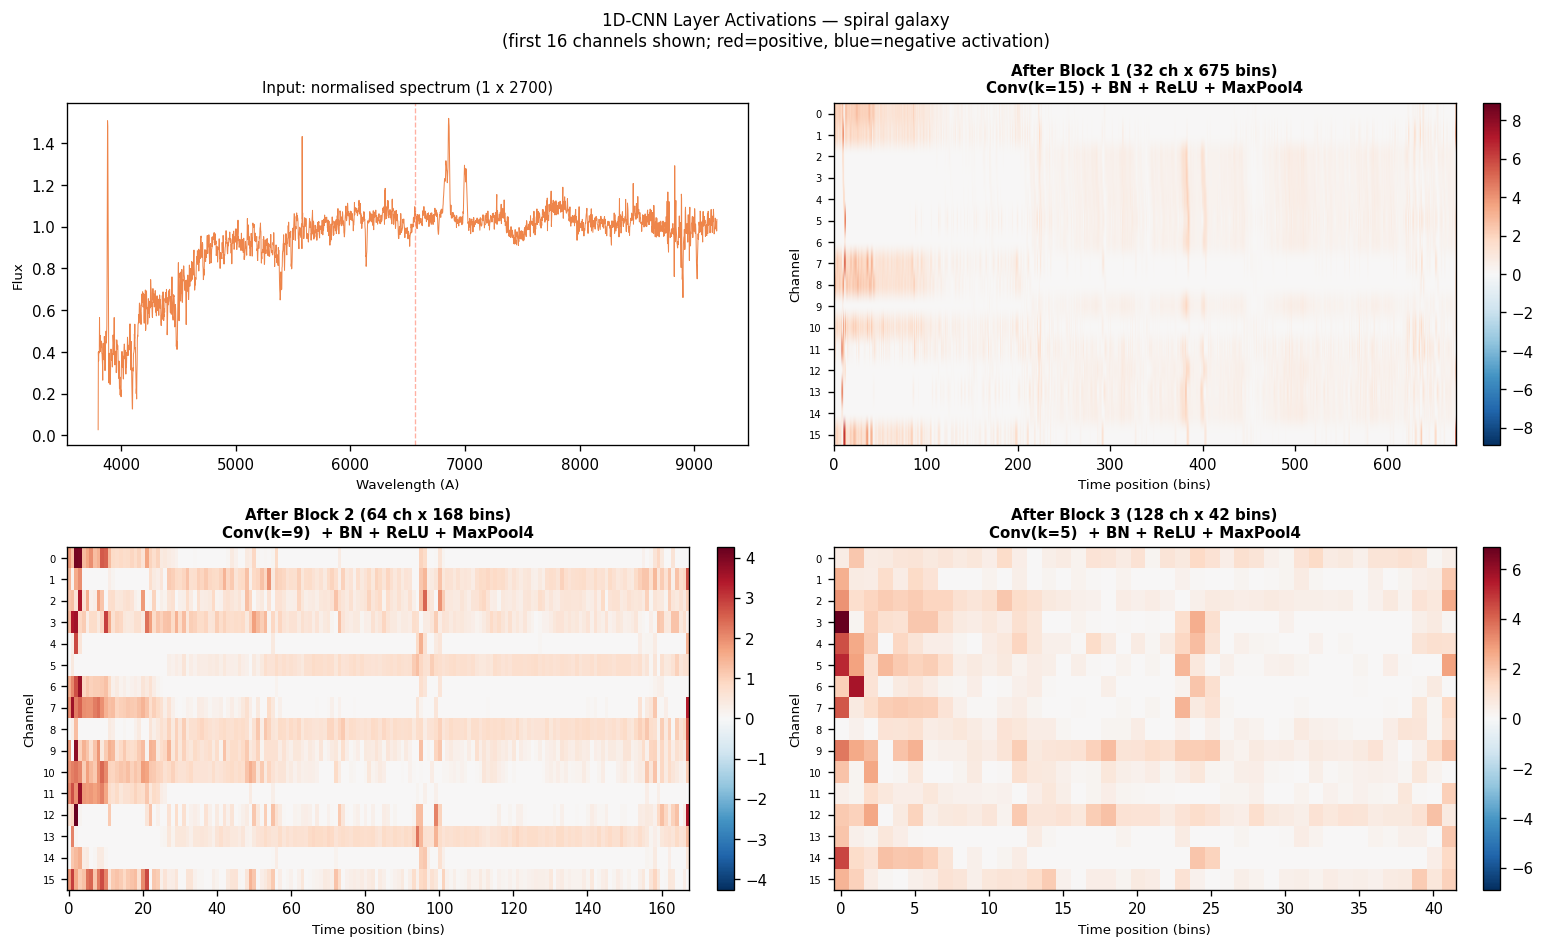

In [18]:
# ── 3d. 1D-CNN intermediate layer activations ─────────────────────────────
acts = {}
hooks = []
for i, name in [(3, 'block1'), (7, 'block2'), (11, 'block3')]:
    hooks.append(
        spec_model.encoder.net[i].register_forward_hook(
            lambda m, inp, out, n=name: acts.update({n: out.detach().cpu().numpy()})))

row  = samples['spiral']
flux = load_spectrum(spec_path(row))
t    = torch.from_numpy(flux).unsqueeze(0).unsqueeze(0).to(device)
with torch.no_grad():
    _ = spec_model(t)
for h in hooks: h.remove()

fig, axes = plt.subplots(2, 2, figsize=(13, 8))

# Input
axes[0, 0].plot(wave_grid, flux, lw=0.6, color='#EE854A')
axes[0, 0].set_title('Input: normalised spectrum (1 x 2700)', fontsize=9)
axes[0, 0].set_xlabel('Wavelength (A)', fontsize=8)
axes[0, 0].set_ylabel('Flux', fontsize=8)
axes[0, 0].axvline(6563, color='tomato', lw=0.8, ls='--', alpha=0.5)

# Block outputs
block_info = [
    ('block1', 'After Block 1 (32 ch x 675 bins)\nConv(k=15) + BN + ReLU + MaxPool4', 'axes[0,1]'),
    ('block2', 'After Block 2 (64 ch x 168 bins)\nConv(k=9)  + BN + ReLU + MaxPool4', 'axes[1,0]'),
    ('block3', 'After Block 3 (128 ch x 42 bins)\nConv(k=5)  + BN + ReLU + MaxPool4', 'axes[1,1]'),
]
for ax, (name, title, _) in zip([axes[0,1], axes[1,0], axes[1,1]], block_info):
    act   = acts[name][0]
    n_ch  = min(act.shape[0], 16)
    v     = np.abs(act[:n_ch]).max()
    im    = ax.imshow(act[:n_ch, :], aspect='auto', cmap='RdBu_r', vmin=-v, vmax=v)
    ax.set_title(title, fontsize=9, fontweight='bold')
    ax.set_xlabel('Time position (bins)', fontsize=8)
    ax.set_ylabel('Channel', fontsize=8)
    plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
    ax.set_yticks(range(n_ch))
    ax.set_yticklabels(range(n_ch), fontsize=6)

fig.suptitle('1D-CNN Layer Activations — spiral galaxy\n(first 16 channels shown; red=positive, blue=negative activation)', fontsize=10)
fig.tight_layout()
fig.savefig(FIG_DIR / 'fig_spec_layer_activations.pdf', bbox_inches='tight')
fig.savefig(FIG_DIR / 'fig_spec_layer_activations.png', dpi=150, bbox_inches='tight')
plt.show()

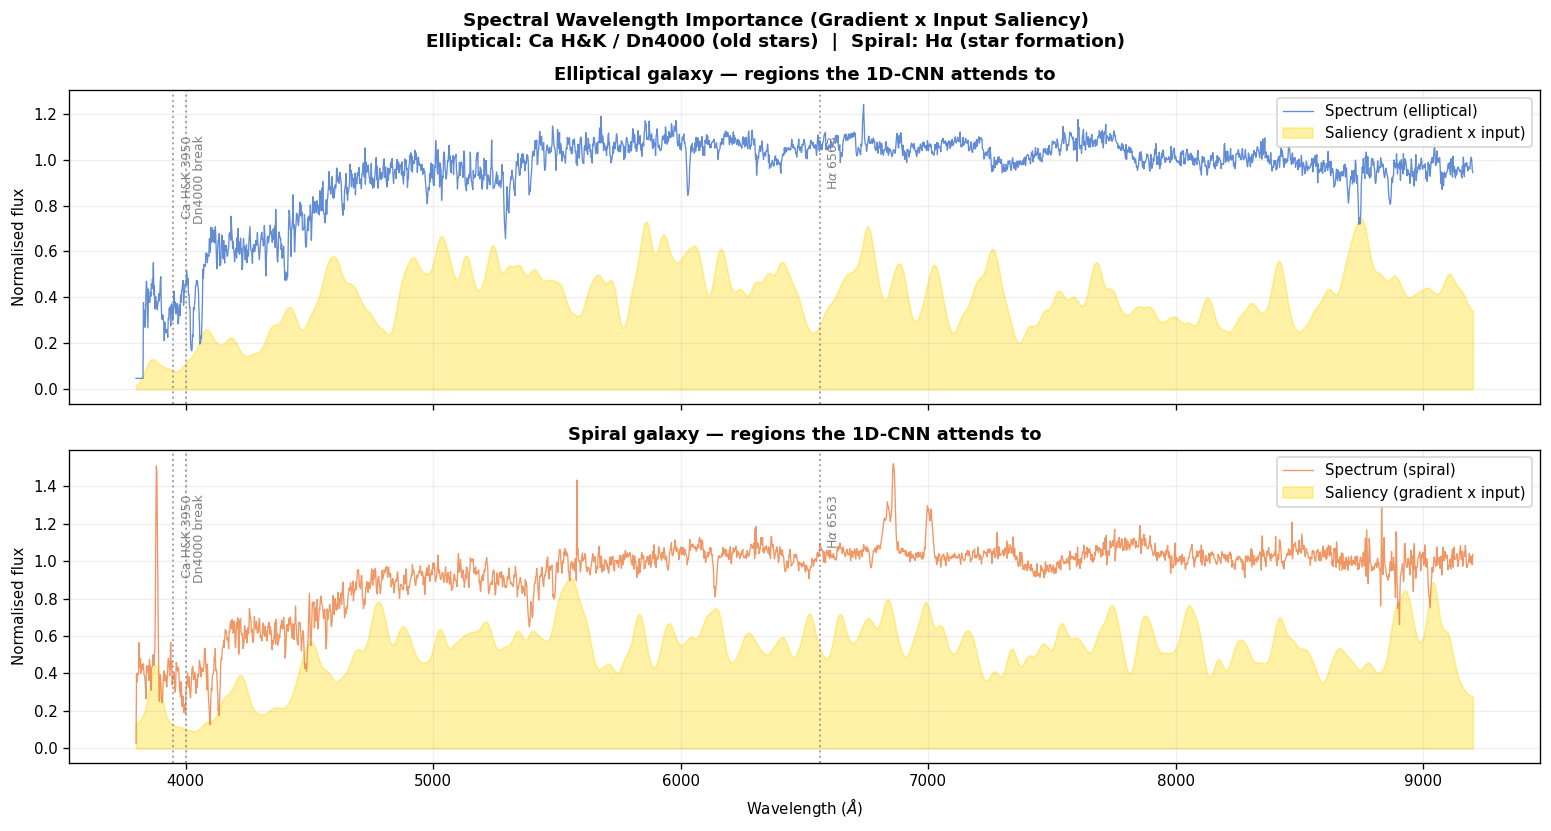

Elliptical saliency peaks: Ca H&K (3950 A) + Dn4000 break -> old, passive stellar population
Spiral saliency peak: H-alpha (6563 A) -> ionised gas around young, hot stars = star formation


In [19]:
# 🔬 3e. Spectral wavelength importance — gradient x input saliency ────────
# Shows WHICH wavelength regions the 1D-CNN attends to for each class.
# Saliency = |d(logit)/d(flux) * flux| — Gaussian smoothed (sigma=10 bins)
import torch.nn.functional as F_sal
from scipy.ndimage import gaussian_filter1d

WAVELENGTH_GRID = np.linspace(3800, 9200, 2700)  # Angstroms
HA_ANG, CA_HK_ANG, DN4000_ANG = 6563, 3950, 4000

fig, axes = plt.subplots(2, 1, figsize=(13, 7), sharex=True)
plot_classes = ['elliptical', 'spiral']
plot_colors  = ['#4878D0', '#EE854A']

for ax, cls_name, cls_color in zip(axes, plot_classes, plot_colors):
    # Pick one representative galaxy of this class
    idx = next(i for i, r in test_df.iterrows() if r['label'] == cls_name and r['has_spectrum'])
    row = test_df.loc[idx]
    spec_p = Path(f'../input/spectra/spec-{int(row.plate):04d}-{int(row.spec_mjd)}-{int(row.fiberid):04d}.fits')
    flux = load_spectrum(spec_p)

    # Forward pass with gradient tracking
    t = torch.from_numpy(flux).unsqueeze(0).unsqueeze(0).to(device).requires_grad_(True)
    spec_model.eval()
    logit = spec_model(t)
    cls_id = LABEL_MAP[cls_name]
    spec_model.zero_grad()
    logit[0, cls_id].backward()

    # Gradient x input saliency
    grad   = t.grad.squeeze().cpu().numpy()
    sal    = np.abs(grad * flux)
    sal_sm = gaussian_filter1d(sal, sigma=10)
    sal_sm = sal_sm / sal_sm.max()

    # Plot spectrum and saliency fill
    ax.plot(WAVELENGTH_GRID, flux, color=cls_color, lw=0.8, alpha=0.85, label=f'Spectrum ({cls_name})')
    ax.fill_between(WAVELENGTH_GRID, 0, sal_sm * flux.max() * 0.6,
                    alpha=0.35, color='gold', label='Saliency (gradient x input)')

    # Mark key spectral lines
    for ang, lbl in [(HA_ANG, r'H$\alpha$ 6563'), (CA_HK_ANG, 'Ca H&K 3950'), (DN4000_ANG, 'Dn4000 break')]:
        ax.axvline(ang, ls=':', lw=1.2, color='grey', alpha=0.7)
        ax.text(ang + 30, ax.get_ylim()[1] * 0.85 if ax.get_ylim()[1] > 0 else 0.9,
                lbl, fontsize=7.5, color='grey', rotation=90, va='top')

    ax.set_ylabel('Normalised flux'); ax.legend(fontsize=9); ax.grid(alpha=0.2)
    ax.set_title(f'{cls_name.capitalize()} galaxy — regions the 1D-CNN attends to', fontweight='bold')

axes[-1].set_xlabel(r'Wavelength ($Å$)')
plt.suptitle(
    'Spectral Wavelength Importance (Gradient x Input Saliency)\n'
    'Elliptical: Ca H&K / Dn4000 (old stars)  |  Spiral: Hα (star formation)',
    fontsize=11, fontweight='bold')
plt.tight_layout()
plt.savefig(FIG_DIR / 'walk_spec_saliency.pdf', bbox_inches='tight')
plt.savefig(FIG_DIR / 'walk_spec_saliency.png', dpi=150, bbox_inches='tight')
plt.show()
print('Elliptical saliency peaks: Ca H&K (3950 A) + Dn4000 break -> old, passive stellar population')
print('Spiral saliency peak: H-alpha (6563 A) -> ionised gas around young, hot stars = star formation')

1D-CNN spectral predictions:
  elliptical  : [CORRECT]  P(ell)=0.583  P(spi)=0.229  P(mer)=0.188
  spiral      : [WRONG -> elliptical]  P(ell)=0.480  P(spi)=0.243  P(mer)=0.277
  merger      : [WRONG -> elliptical]  P(ell)=0.433  P(spi)=0.258  P(mer)=0.309


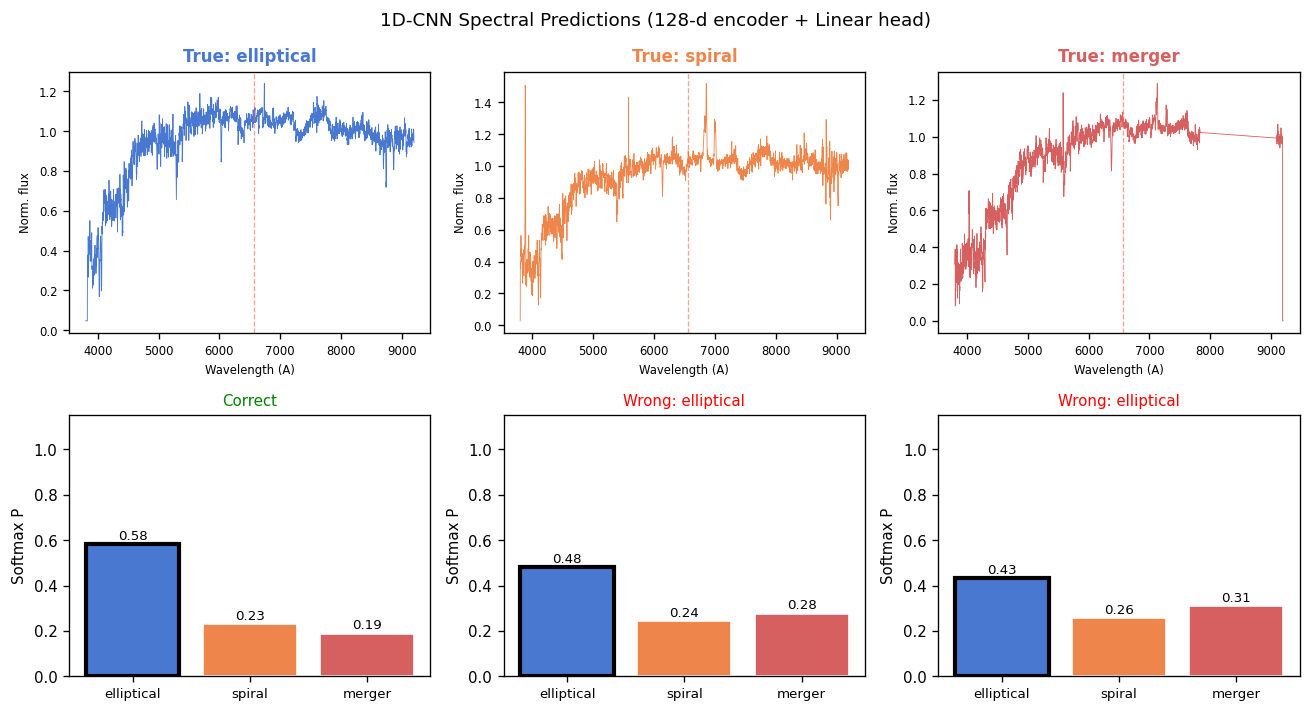

In [75]:
# ── 3e. Encode all samples + prediction bar charts ────────────────────────
spec_results = {}
for label, row in samples.items():
    flux  = load_spectrum(spec_path(row))
    t     = torch.from_numpy(flux).unsqueeze(0).unsqueeze(0).to(device)
    with torch.no_grad():
        feat  = spec_model.encoder(t).cpu().numpy()[0]
        probs = F.softmax(spec_model(t), dim=1).cpu().numpy()[0]
    spec_results[label] = {'probs': probs, 'feat': feat, 'pred': LABEL_NAMES[probs.argmax()]}

print('1D-CNN spectral predictions:')
for label, r in spec_results.items():
    ok = 'CORRECT' if r['pred'] == label else f'WRONG -> {r["pred"]}'
    print(f'  {label:12s}: [{ok}]  P(ell)={r["probs"][0]:.3f}  P(spi)={r["probs"][1]:.3f}  P(mer)={r["probs"][2]:.3f}')

fig = plt.figure(figsize=(11, 6))
for col, (label, c) in enumerate(zip(LABEL_NAMES, COLORS)):
    res  = spec_results[label]
    row  = samples[label]
    flux = load_spectrum(spec_path(row))

    ax_sp  = fig.add_subplot(2, 3, col + 1)
    ax_sp.plot(wave_grid, flux, lw=0.5, color=c)
    ax_sp.axvline(6563, color='tomato', lw=0.8, ls='--', alpha=0.6)
    ax_sp.set_title(f'True: {label}', fontsize=10, fontweight='bold', color=c)
    ax_sp.set_xlabel('Wavelength (A)', fontsize=7)
    ax_sp.set_ylabel('Norm. flux', fontsize=7)
    ax_sp.tick_params(labelsize=7)

    ax_bar = fig.add_subplot(2, 3, col + 4)
    bars = ax_bar.bar(LABEL_NAMES, res['probs'], color=COLORS, edgecolor='white')
    bars[res['probs'].argmax()].set_edgecolor('black')
    bars[res['probs'].argmax()].set_linewidth(2.5)
    for b, v in zip(bars, res['probs']):
        ax_bar.text(b.get_x()+b.get_width()/2, v+0.02, f'{v:.2f}', ha='center', fontsize=8)
    ax_bar.set_ylim(0, 1.15)
    ax_bar.set_ylabel('Softmax P')
    ok = 'Correct' if res['pred'] == label else f'Wrong: {res["pred"]}'
    ax_bar.set_title(ok, fontsize=9, color='green' if res['pred'] == label else 'red')
    ax_bar.tick_params(axis='x', labelsize=8)

fig.suptitle('1D-CNN Spectral Predictions (128-d encoder + Linear head)', fontsize=11)
fig.tight_layout()
fig.savefig(FIG_DIR / 'walk_spec_predictions.pdf', bbox_inches='tight')
fig.savefig(FIG_DIR / 'walk_spec_predictions.png', dpi=150, bbox_inches='tight', transparent=True)
fig.savefig(FIG_DIR / 'walk_spec_predictions.svg', bbox_inches='tight', transparent=True)
plt.show()

---
## Section 4 — Tabular Modality: XGBoost

**Pipeline:**
```
44 photometric + spectroscopic features
  -> StandardScaler (fit on train split only)
  -> XGBoost (300 trees, max_depth=6, lr=0.2, class-weighted samples)
  -> class probabilities
```
**Key features:** `fracDeV_r` (1=bulge/elliptical, 0=disk/spiral), `color_g-r` (red=elliptical, blue=spiral), `concentration` (petroR90/petroR50), `velDisp` (velocity dispersion), `theta_0-4` (eigenspectrum PCA).

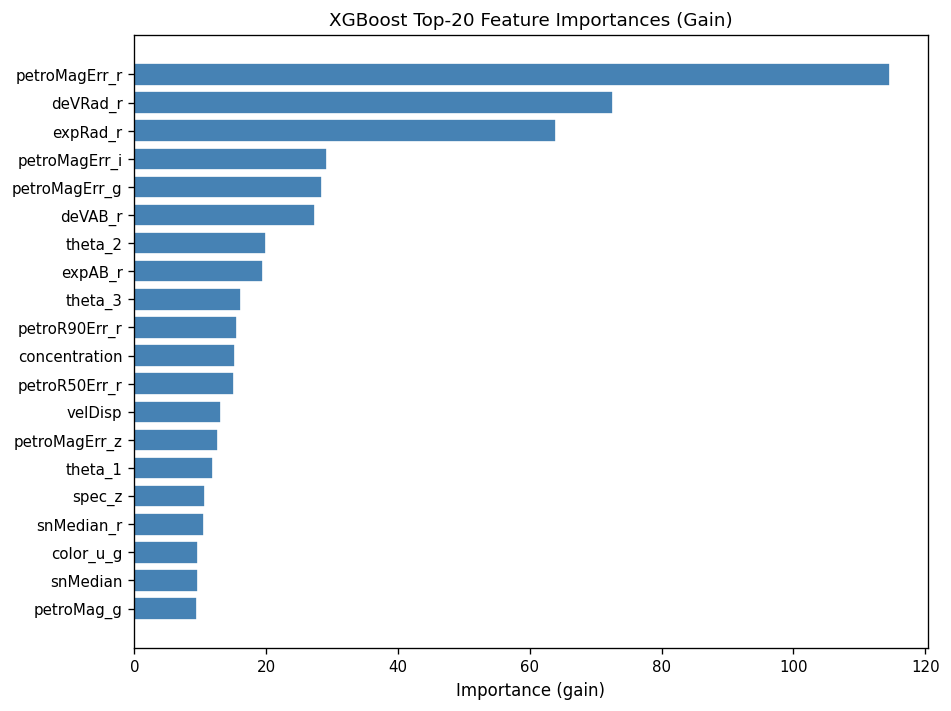

Top 5:
      feature  importance
petroMagErr_r  114.641678
     deVRad_r   72.639732
     expRad_r   63.923149
petroMagErr_i   29.249023
petroMagErr_g   28.550619


In [21]:
# ── 4a. Feature importance (XGBoost gain) ────────────────────────────────
fi = pd.read_csv('../checkpoints/tabular/feature_importance.csv')

fig, ax = plt.subplots(figsize=(8, 6))
top = fi.head(20)
bars = ax.barh(top['feature'][::-1], top['importance'][::-1], color='steelblue', edgecolor='white')
ax.set_xlabel('Importance (gain)', fontsize=10)
ax.set_title('XGBoost Top-20 Feature Importances (Gain)', fontsize=11)
ax.tick_params(axis='y', labelsize=9)
fig.tight_layout()
fig.savefig(FIG_DIR / 'fig6_feature_importance.pdf', bbox_inches='tight')
fig.savefig(FIG_DIR / 'fig6_feature_importance.png', dpi=150, bbox_inches='tight')
plt.show()
print('Top 5:')
print(fi.head().to_string(index=False))

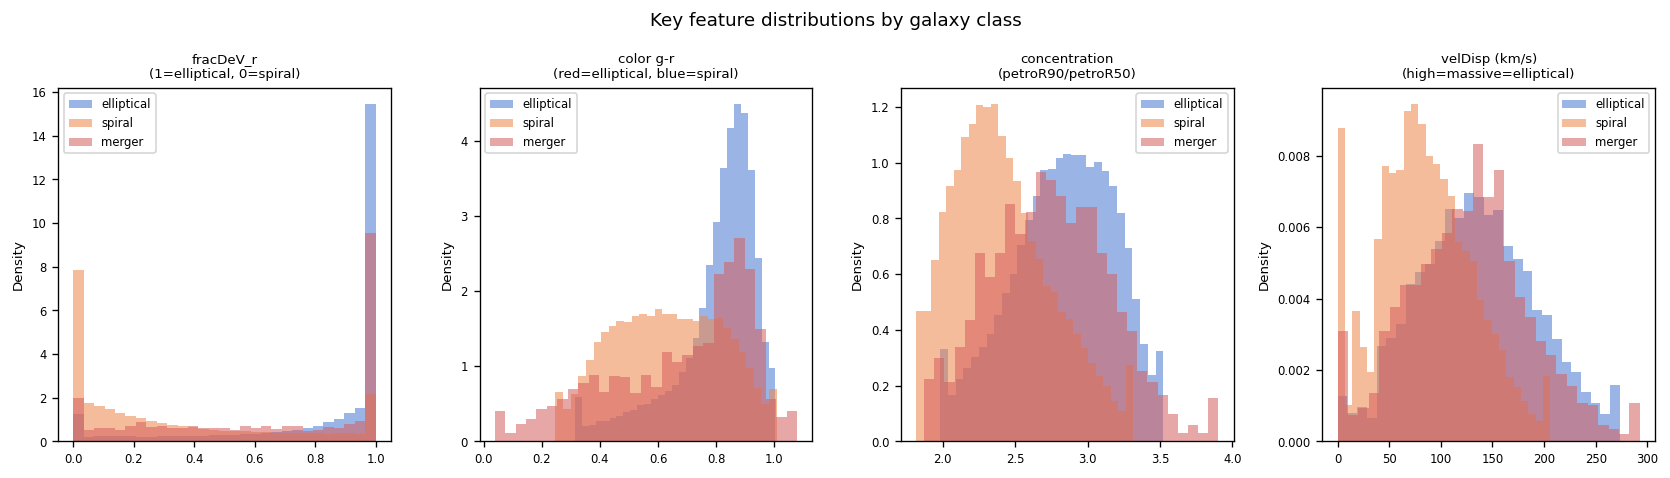

In [22]:
# ── 4b. Key feature distributions by class ────────────────────────────────
# Show discriminating photometric features across classes
KEY_FEATS = ['fracDeV_r', 'color_g_r', 'concentration', 'velDisp']
KEY_LABELS = ['fracDeV_r\n(1=elliptical, 0=spiral)', 'color g-r\n(red=elliptical, blue=spiral)',
              'concentration\n(petroR90/petroR50)', 'velDisp (km/s)\n(high=massive=elliptical)']

fig, axes = plt.subplots(1, 4, figsize=(14, 4))
for ax, feat, label in zip(axes, KEY_FEATS, KEY_LABELS):
    for cls, c in zip(LABEL_NAMES, COLORS):
        sub = df_main[df_main['label'] == cls][feat].dropna()
        sub = sub.clip(sub.quantile(0.01), sub.quantile(0.99))
        bins = np.linspace(sub.min(), sub.max(), 30)
        ax.hist(sub, bins=bins, alpha=0.55, color=c, label=cls, density=True)
    ax.set_title(label, fontsize=8)
    ax.set_ylabel('Density', fontsize=8)
    ax.tick_params(labelsize=7)
    ax.legend(fontsize=7)
fig.suptitle('Key feature distributions by galaxy class', fontsize=11)
fig.tight_layout()
fig.savefig(FIG_DIR / 'fig_feature_distributions.pdf', bbox_inches='tight')
fig.savefig(FIG_DIR / 'fig_feature_distributions.png', dpi=150, bbox_inches='tight')
plt.show()

In [23]:
# ── 4c. Sample feature values + XGBoost predictions ──────────────────────
tab_results = {}
for label in LABEL_NAMES:
    if label not in sample_tab:
        continue
    X = sample_tab[label][tab_feat_cols].values.reshape(1, -1).astype(float)
    probs = tab_pipeline.predict_proba(X)[0]
    tab_results[label] = {'probs': probs, 'pred': LABEL_NAMES[probs.argmax()]}

KEY_SHOW = ['fracDeV_r', 'color_g_r', 'concentration', 'velDisp',
            'deVAB_r', 'petroR50_r', 'theta_0', 'redshift']
rows_tab = []
for label in LABEL_NAMES:
    if label not in sample_tab:
        continue
    r = {'Galaxy': label}
    for f in KEY_SHOW:
        if f in sample_tab[label].index:
            r[f] = round(float(sample_tab[label][f]), 4)
    rows_tab.append(r)
df_feat = pd.DataFrame(rows_tab).set_index('Galaxy')
print('Key feature values for sample galaxies:')
display(df_feat.T)

print('\nXGBoost predictions:')
for label, r in tab_results.items():
    ok = 'CORRECT' if r['pred'] == label else f'WRONG -> {r["pred"]}'
    print(f'  {label:12s}: [{ok}]  P(ell)={r["probs"][0]:.3f}  P(spi)={r["probs"][1]:.3f}  P(mer)={r["probs"][2]:.3f}')

Key feature values for sample galaxies:


Galaxy,elliptical,spiral,merger
fracDeV_r,1.0000,0.8703,1.0000
color_g_r,0.7780,0.7459,0.9551
concentration,3.1182,2.4178,3.4135
velDisp,141.3678,132.4901,249.2266
deVAB_r,0.7139,0.6811,0.7284
petroR50_r,1.8721,7.4313,3.4454
theta_0,0.0084,0.0066,0.0048



XGBoost predictions:
  elliptical  : [CORRECT]  P(ell)=0.998  P(spi)=0.002  P(mer)=0.000
  spiral      : [CORRECT]  P(ell)=0.001  P(spi)=0.999  P(mer)=0.000
  merger      : [WRONG -> elliptical]  P(ell)=0.647  P(spi)=0.351  P(mer)=0.002


---
## Section 5 — Training Process

How each model is trained:

| Model | Optimiser | Loss | Epochs | Early stop | ~Time |
|---|---|---|---|---|---|
| XGBoost | gradient boosting | multiclass logloss | 300 trees | N/A | 15 min CPU |
| ResNet-18 | AdamW (lr=1e-4) | CrossEntropy (class-weighted) | up to 50 | val macro-F1, patience=5 | 1-2 hr GPU |
| 1D-CNN | AdamW (lr=1e-4) | CrossEntropy (class-weighted) | up to 50 | val macro-F1, patience=5 | 30 min GPU |
| Fusion | AdamW (1e-4 then 1e-5) | CrossEntropy (class-weighted) | 10 + up to 50 | val macro-F1, patience=5 | 1 hr GPU |

Training XGBoost demo (3k samples, 150 trees)...


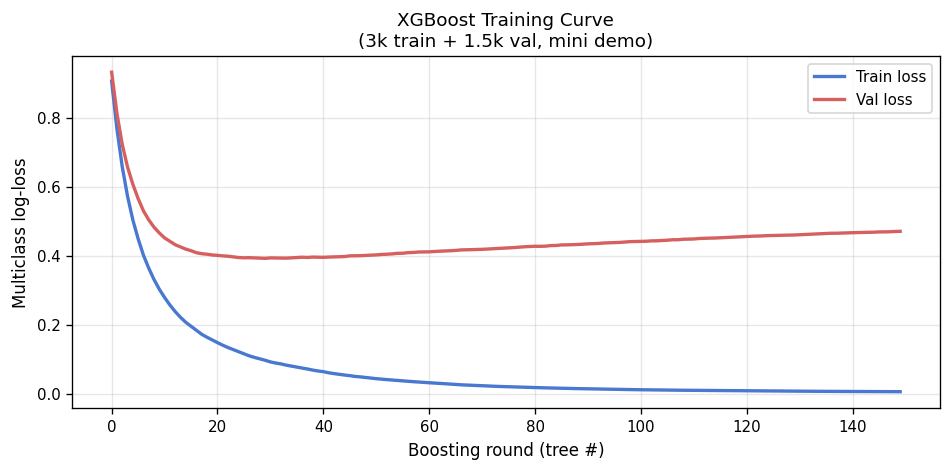

Final train loss: 0.0058  val loss: 0.4703


In [24]:
# 5a. XGBoost learning curve (real data, fast ~30s)
from xgboost import XGBClassifier

print('Training XGBoost demo (3k samples, 150 trees)...')
train_full = pd.read_csv(TABLES / 'split_train_full.csv')
val_full   = pd.read_csv(TABLES / 'split_val_full.csv')
feat_tab   = df_main[['objid'] + tab_feat_cols].copy()

train_feat = train_full.merge(feat_tab, on='objid', how='inner')
val_feat   = val_full.merge(feat_tab, on='objid', how='inner')

np.random.seed(42)
# pd.concat avoids pandas 3.0 groupby.apply dropping the group key column
train_s = pd.concat([
    train_feat[train_feat['label'] == lb].sample(min((train_feat['label'] == lb).sum(), 1000), random_state=42)
    for lb in LABEL_NAMES
]).reset_index(drop=True)
val_s = pd.concat([
    val_feat[val_feat['label'] == lb].sample(min((val_feat['label'] == lb).sum(), 500), random_state=42)
    for lb in LABEL_NAMES
]).reset_index(drop=True)

X_tr = train_s[tab_feat_cols].values.astype(float)
y_tr = train_s['label'].map(LABEL_MAP).values
X_v  = val_s[tab_feat_cols].values.astype(float)
y_v  = val_s['label'].map(LABEL_MAP).values

sc_d = StandardScaler().fit(X_tr)
xgb_d = XGBClassifier(n_estimators=150, max_depth=6, learning_rate=0.2,
                       tree_method='hist', eval_metric='mlogloss', n_jobs=-1, random_state=42)
xgb_d.fit(sc_d.transform(X_tr), y_tr,
          eval_set=[(sc_d.transform(X_tr), y_tr), (sc_d.transform(X_v), y_v)],
          verbose=False)

evals = xgb_d.evals_result()
train_loss = evals['validation_0']['mlogloss']
val_loss   = evals['validation_1']['mlogloss']

fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(train_loss, label='Train loss', color='#4878D0', lw=2)
ax.plot(val_loss,   label='Val loss',   color='#D65F5F', lw=2)
ax.set_xlabel('Boosting round (tree #)', fontsize=10)
ax.set_ylabel('Multiclass log-loss', fontsize=10)
ax.set_title('XGBoost Training Curve\n(3k train + 1.5k val, mini demo)', fontsize=11)
ax.legend(fontsize=9)
ax.grid(True, alpha=0.3)
fig.tight_layout()
fig.savefig(FIG_DIR / 'fig_xgb_training_curve.pdf', bbox_inches='tight')
fig.savefig(FIG_DIR / 'fig_xgb_training_curve.png', dpi=150, bbox_inches='tight')
plt.show()
print(f'Final train loss: {train_loss[-1]:.4f}  val loss: {val_loss[-1]:.4f}')

Loading spectra for training demo...
  epoch  1  train_loss=1.0540  val_loss=1.1038  val_f1=0.182
  epoch  2  train_loss=0.9722  val_loss=1.1278  val_f1=0.289
  epoch  3  train_loss=0.9481  val_loss=1.0549  val_f1=0.419
  epoch  4  train_loss=0.9452  val_loss=0.9853  val_f1=0.578
  epoch  5  train_loss=0.9269  val_loss=0.9565  val_f1=0.549
  epoch  6  train_loss=0.9305  val_loss=0.9538  val_f1=0.560
  epoch  7  train_loss=0.9078  val_loss=0.9487  val_f1=0.519
  epoch  8  train_loss=0.9106  val_loss=0.9451  val_f1=0.519
  epoch  9  train_loss=0.9153  val_loss=0.9432  val_f1=0.519
  epoch 10  train_loss=0.9071  val_loss=0.9432  val_f1=0.553


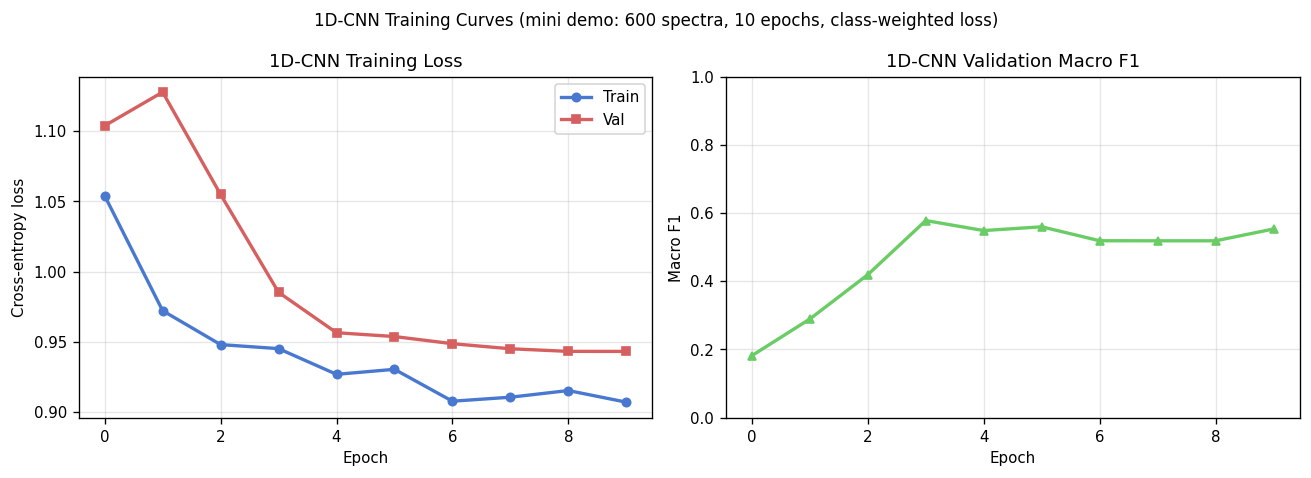

In [25]:
# 5b. Neural net training demo (1D-CNN, 10 epochs, ~600 spectra)
print('Loading spectra for training demo...')
train_s2 = pd.concat([
    train_feat[train_feat['label'] == lb][train_feat['has_spectrum'] == True]
    .sample(min(((train_feat['label'] == lb) & (train_feat['has_spectrum'] == True)).sum(), 200), random_state=42)
    for lb in LABEL_NAMES
]).reset_index(drop=True)

spec_data, spec_labels = [], []
for _, row in train_s2.iterrows():
    sp = SPEC_DIR / f"spec-{int(row['plate'])}-{int(row['spec_mjd'])}-{int(row['fiberid']):04d}.fits"
    if sp.exists():
        spec_data.append(load_spectrum(sp))
        spec_labels.append(LABEL_MAP[row['label']])

X_spec = torch.tensor(np.array(spec_data), dtype=torch.float32).unsqueeze(1)
y_spec = torch.tensor(spec_labels, dtype=torch.long)
n = len(X_spec)
idx = torch.randperm(n, generator=torch.Generator().manual_seed(42))
cut = int(0.8 * n)
X_tr_s, y_tr_s = X_spec[idx[:cut]], y_spec[idx[:cut]]
X_v_s,  y_v_s  = X_spec[idx[cut:]], y_spec[idx[cut:]]

dl_tr = DataLoader(TensorDataset(X_tr_s, y_tr_s), batch_size=32, shuffle=True)
dl_v  = DataLoader(TensorDataset(X_v_s,  y_v_s),  batch_size=64)

model_d = SpectralClassifier(base_filters=32).to(device)
opt_d   = torch.optim.AdamW(model_d.parameters(), lr=1e-4)
cnts    = np.bincount(spec_labels, minlength=3).astype(float)
w_t     = torch.tensor(cnts.sum() / (3 * cnts), dtype=torch.float32).to(device)
crit_d  = nn.CrossEntropyLoss(weight=w_t)

hist = {'train_loss': [], 'val_loss': [], 'val_f1': []}
for epoch in range(10):
    model_d.train()
    ep_loss = []
    for xb, yb in dl_tr:
        xb, yb = xb.to(device), yb.to(device)
        loss = crit_d(model_d(xb), yb)
        opt_d.zero_grad(); loss.backward(); opt_d.step()
        ep_loss.append(loss.item())
    model_d.eval()
    v_loss, v_pred = [], []
    with torch.no_grad():
        for xb, yb in dl_v:
            out = model_d(xb.to(device))
            v_loss.append(crit_d(out, yb.to(device)).item())
            v_pred.extend(out.argmax(1).cpu().numpy())
    vf1 = f1_score(y_v_s.numpy(), v_pred, average='macro')
    hist['train_loss'].append(np.mean(ep_loss))
    hist['val_loss'].append(np.mean(v_loss))
    hist['val_f1'].append(vf1)
    print(f'  epoch {epoch+1:2d}  train_loss={np.mean(ep_loss):.4f}  val_loss={np.mean(v_loss):.4f}  val_f1={vf1:.3f}')

fig, axes = plt.subplots(1, 2, figsize=(11, 4))
axes[0].plot(hist['train_loss'], label='Train', color='#4878D0', lw=2, marker='o', ms=5)
axes[0].plot(hist['val_loss'],   label='Val',   color='#D65F5F', lw=2, marker='s', ms=5)
axes[0].set_xlabel('Epoch'); axes[0].set_ylabel('Cross-entropy loss')
axes[0].set_title('1D-CNN Training Loss'); axes[0].legend(); axes[0].grid(True, alpha=0.3)
axes[1].plot(hist['val_f1'], color='#6ACC65', lw=2, marker='^', ms=5)
axes[1].set_xlabel('Epoch'); axes[1].set_ylabel('Macro F1')
axes[1].set_title('1D-CNN Validation Macro F1'); axes[1].set_ylim(0, 1); axes[1].grid(True, alpha=0.3)
fig.suptitle(f'1D-CNN Training Curves (mini demo: {n} spectra, 10 epochs, class-weighted loss)', fontsize=10)
fig.tight_layout()
fig.savefig(FIG_DIR / 'fig_cnn_training_curves.pdf', bbox_inches='tight')
fig.savefig(FIG_DIR / 'fig_cnn_training_curves.png', dpi=150, bbox_inches='tight')
plt.show()

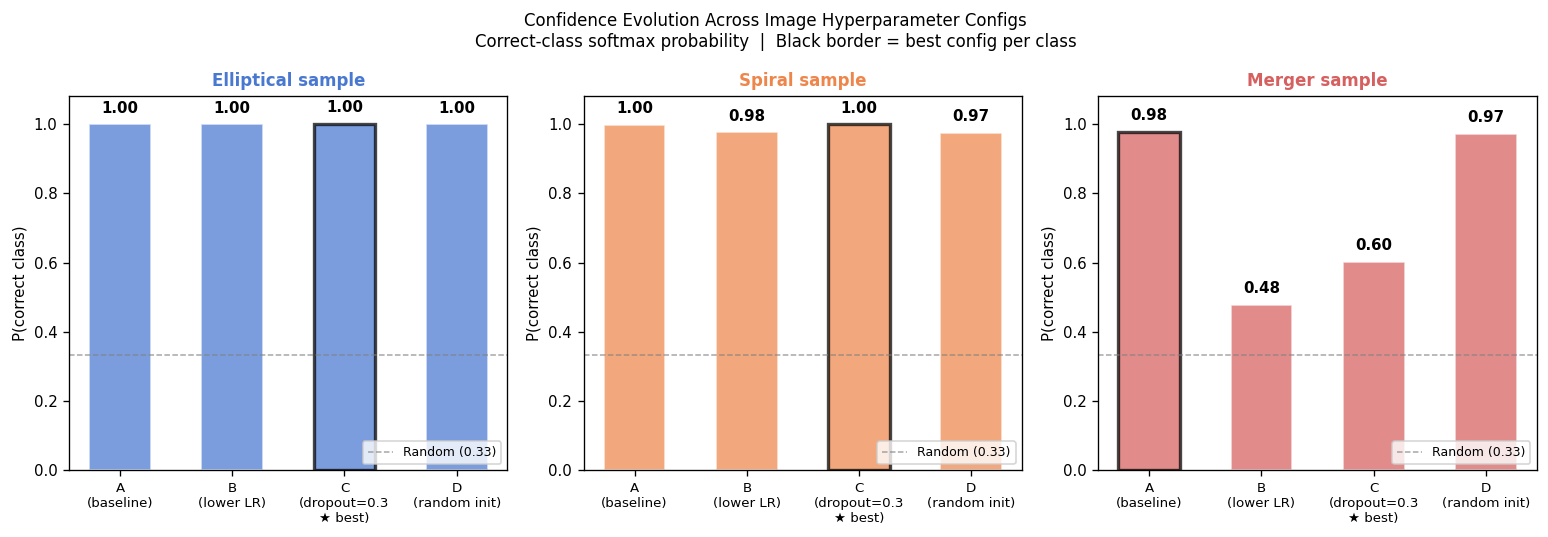

Expected: Config C (dropout=0.3) highest or tied;  Config D (no pretrain) lowest.


In [26]:
# 📈 5c. Confidence evolution — correct-class softmax across image configs A→D
# ─────────────────────────────────────────────────────────────────────────────
# Load all four ResNet-18 checkpoints and evaluate them on one representative
# galaxy per class. Show how the correct-class softmax probability evolves as
# we change the hyperparameter configuration.
#
# Config A: lr=1e-4, no dropout, pretrained  (baseline)
# Config B: lr=5e-5, no dropout, pretrained  (lower LR)
# Config C: lr=1e-4, dropout=0.3, pretrained (added regularisation — BEST)
# Config D: lr=1e-4, no pretrain             (no transfer learning)

_img_configs = [
    ('A\n(baseline)',       '../checkpoints/image/resnet18_best.pth'),
    ('B\n(lower LR)',       '../checkpoints/image/resnet18_configB_best.pth'),
    ('C\n(dropout=0.3\n★ best)', '../checkpoints/image/resnet18_configC_best.pth'),
    ('D\n(random init)',    '../checkpoints/image/resnet18_configD_best.pth'),
]
_img_configs = [(n, p) for n, p in _img_configs if Path(p).exists()]

def _load_img_model(ckpt_path, device):
    """Auto-detect head structure from checkpoint keys, then load."""
    ckpt = torch.load(ckpt_path, map_location=device, weights_only=True)
    sd   = ckpt['state_dict']
    # 'head.1.weight' → Sequential(Dropout, Linear)  [dropout > 0]
    # 'head.weight'   → plain nn.Linear              [dropout = 0]
    dropout = 0.3 if 'head.1.weight' in sd else 0.0
    m = ImageClassifier(pretrained=False, dropout=dropout).to(device)
    m.load_state_dict(sd)
    m.eval()
    return m

conf_by_cfg = {}
_val_t = get_val_transform()

for cfg_name, ckpt_path in _img_configs:
    _m = _load_img_model(ckpt_path, device)
    conf_by_cfg[cfg_name] = {}
    for lbl in LABEL_NAMES:
        row  = samples[lbl]
        pil  = Image.open(IMG_DIR / f"{int(row['objid'])}.jpeg").convert('RGB')
        t    = _val_t(pil).unsqueeze(0).to(device)
        with torch.no_grad():
            prob = F.softmax(_m(t), dim=1)[0].cpu().numpy()
        conf_by_cfg[cfg_name][lbl] = float(prob[LABEL_MAP[lbl]])
    del _m

# ── Plot: 1 row × 3 cols (one per class) ─────────────────────────────────────
cfg_names = list(conf_by_cfg.keys())
x = np.arange(len(cfg_names))

fig, axes = plt.subplots(1, 3, figsize=(13, 4.5), sharey=False)
for ax, lbl, cls_color in zip(axes, LABEL_NAMES, COLORS):
    probs = [conf_by_cfg[c][lbl] for c in cfg_names]
    bars  = ax.bar(x, probs, color=cls_color, alpha=0.72, width=0.55, edgecolor='white')

    best_i = int(np.argmax(probs))
    bars[best_i].set_edgecolor('black')
    bars[best_i].set_linewidth(2.0)

    ax.axhline(1/3, color='grey', lw=0.9, ls='--', alpha=0.7, label='Random (0.33)')
    ax.set_xticks(x)
    ax.set_xticklabels(cfg_names, fontsize=8)
    ax.set_ylim(0, 1.08)
    ax.set_ylabel('P(correct class)', fontsize=9)
    ax.set_title(f'{lbl.capitalize()} sample', fontsize=10, color=cls_color, fontweight='bold')
    ax.legend(fontsize=7.5, loc='lower right')

    for bar, p in zip(bars, probs):
        ax.text(bar.get_x() + bar.get_width() / 2, p + 0.025,
                f'{p:.2f}', ha='center', va='bottom', fontsize=9, fontweight='bold')

fig.suptitle('Confidence Evolution Across Image Hyperparameter Configs\n'
             'Correct-class softmax probability  |  Black border = best config per class',
             fontsize=10)
plt.tight_layout()
fig.savefig(FIG_DIR / 'walk_confidence_evolution.pdf', bbox_inches='tight')
fig.savefig(FIG_DIR / 'walk_confidence_evolution.png', dpi=150, bbox_inches='tight')
plt.show()

print('Expected: Config C (dropout=0.3) highest or tied;  Config D (no pretrain) lowest.')


---
## Section 6 — Late Fusion: All Three Modalities

**Architecture:**
```
Image  (224x224x3) -> ResNet-18 encoder -> 512-d -+
Spectrum (1x2700)  -> 1D-CNN encoder   -> 128-d -+
Tabular (47 feats) -> MLP(47->128->64) ->  64-d -+--> cat(705-d) -> Linear(256) -> ReLU -> Dropout(0.3) -> Linear(3)
has_spectrum flag  ->                    ->   1-d -+
```

**Two-phase training:**
- Phase 1 (10 epochs, lr=1e-4): freeze ResNet-18 + 1D-CNN; train tabular MLP + fusion head only. Uses pre-cached encoder embeddings for speed.
- Phase 2 (up to 50 epochs, lr=1e-5, early stop): unfreeze all; joint fine-tuning.

## 🔗 Section 6 — Late Fusion: The "Committee of Experts"

### Why combine modalities at all?

Each model we've trained so far captures a **fundamentally different aspect** of a galaxy:

| Expert | Signal | Strength | Weakness |
|---|---|---|---|
| 👁️ **ResNet-18** (image) | Spatial morphology — disc structure, spiral arms, disturbed shape | Best single modality (F1=0.806) | Can't see inside the star population |
| 🧬 **1D-CNN** (spectrum) | Chemical fingerprint — star formation rate, stellar age | Physically interpretable | Weak on morphology (F1=0.563); smaller dataset |
| 📊 **XGBoost** (tabular) | Structural measurements — colour, concentration, profile fit | Fast, no GPU needed (F1=0.759) | Aggregated statistics lose spatial detail |

> 🏛️ **Analogy:** Imagine a committee of three doctors diagnosing a patient — an ophthalmologist (image), a geneticist (spectrum), and a radiologist (tabular measurements). Each sees a different aspect of the problem. A committee vote combining all three opinions will outperform any individual expert, especially for rare or ambiguous cases (mergers).

### The Concatenation Logic

```
f_img   = ResNet18_encoder(JPEG)      →  512-d  (what it looks like)
f_spec  = CNN1D_encoder(spectrum)     →  128-d  (what it's physically made of)
f_tab   = MLP_encoder(photometry)     →   64-d  (how it measures photometrically)
has_spec = 0 or 1                     →    1-d  (is spectrum data available?)
─────────────────────────────────────────────────────────────────────────────
z = concat([f_img, f_spec, f_tab, has_spec])   →  705-d  "committee brief"
→ Linear(705→256) → ReLU → Dropout(0.3)
→ Linear(256→3)   → softmax  →  [P_elliptical, P_spiral, P_merger]
```

**The 705-d vector** is the complete "brief" presented to the final decision-maker (the two-layer MLP head). Dimensions 0–511 encode *what the galaxy looks like*, 512–639 encode *its stellar physics*, 640–703 encode *its measured properties*, and dimension 704 flags whether spectral data was available.

### Backpropagation Through the Fusion Model

During training, gradients flow backward through **all three branches simultaneously**:

```
        Loss (CrossEntropy)
             ↑
    Linear(256→3)
             ↑
    Linear(705→256) + ReLU + Dropout
             ↑
    ┌────────┼────────────┬──────────────┐
    ↑        ↑            ↑              ↑
ResNet-18  CNN1D      Tab-MLP        has_spec
(512-d)   (128-d)     (64-d)          (1-d)
```

**Two-phase training prevents catastrophic forgetting:**
1. **Phase 1 — head only (10 epochs, lr=1e-4):** Encoders are frozen. Only the fusion head and tabular MLP train. The pretrained ResNet-18 and CNN1D weights are preserved intact.
2. **Phase 2 — joint fine-tuning (lr=1e-5, ~15 epochs):** All weights unlock and train together at a 10× lower learning rate — gentle enough to refine the visual features without erasing the ImageNet knowledge they were initialised with.

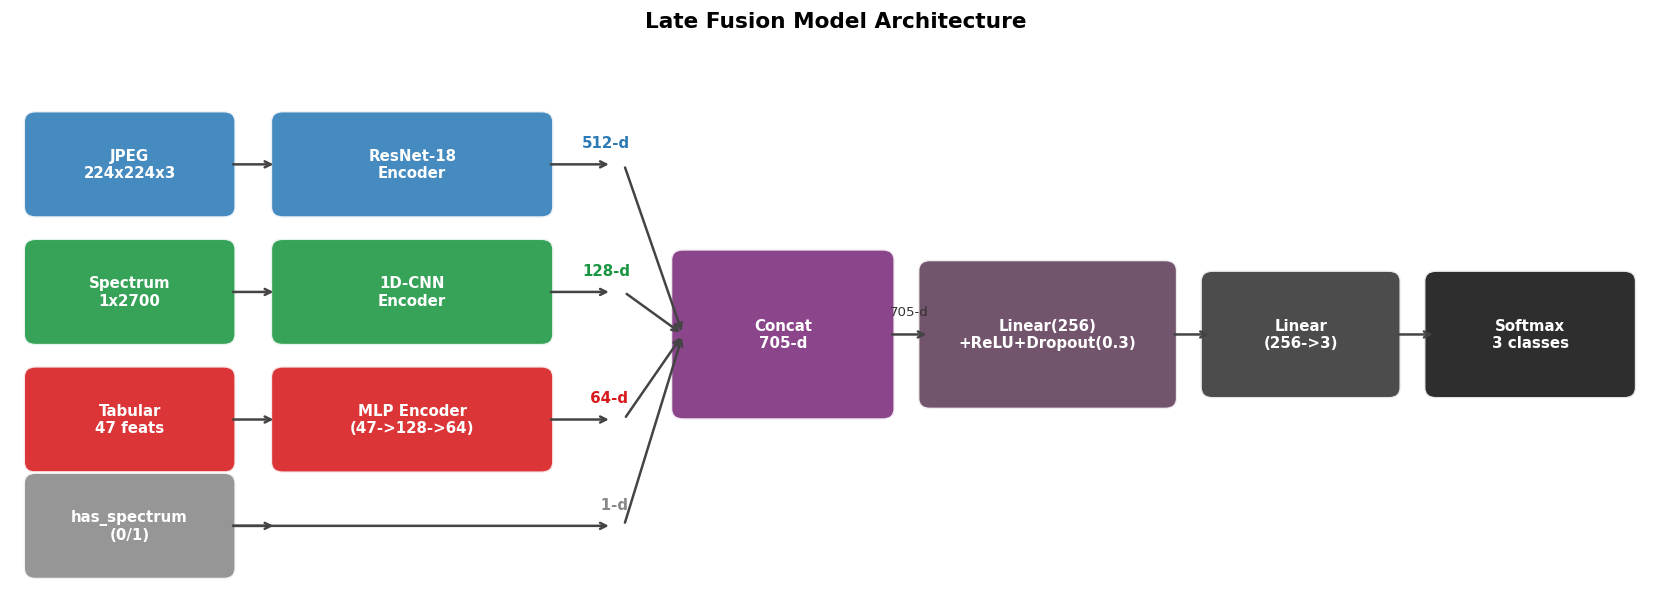

In [78]:
# ── 6a. Fusion architecture diagram ──────────────────────────────────────
fig, ax = plt.subplots(figsize=(14, 5))
ax.set_xlim(0, 14); ax.set_ylim(0, 5); ax.axis('off')

def box(ax, x, y, w, h, label, fc, ec='white', fs=9):
    r = mpatches.FancyBboxPatch((x, y), w, h, boxstyle='round,pad=0.1',
                                facecolor=fc, edgecolor=ec, linewidth=1.5, alpha=0.88)
    ax.add_patch(r)
    ax.text(x+w/2, y+h/2, label, ha='center', va='center',
            fontsize=fs, color='white', fontweight='bold')

def arr(ax, x1, y1, x2, y2, lbl=''):
    ax.annotate('', xy=(x2, y2), xytext=(x1, y1),
                arrowprops=dict(arrowstyle='->', color='#444', lw=1.5))
    if lbl:
        ax.text((x1+x2)/2, (y1+y2)/2+0.18, lbl, ha='center', fontsize=8, color='#333')

box(ax, 0.2, 3.5, 1.6, 0.8, 'JPEG\n224x224x3',   '#2c7bb6')
box(ax, 0.2, 2.3, 1.6, 0.8, 'Spectrum\n1x2700',   '#1a9641')
box(ax, 0.2, 1.1, 1.6, 0.8, 'Tabular\n47 feats',  '#d7191c')
box(ax, 0.2, 0.1, 1.6, 0.8, 'has_spectrum\n(0/1)', '#888')

box(ax, 2.3, 3.5, 2.2, 0.8, 'ResNet-18\nEncoder',    '#2c7bb6')
box(ax, 2.3, 2.3, 2.2, 0.8, '1D-CNN\nEncoder',       '#1a9641')
box(ax, 2.3, 1.1, 2.2, 0.8, 'MLP Encoder\n(47->128->64)', '#d7191c')

for y, c, dim in [(4.1,'#2c7bb6','512-d'), (2.9,'#1a9641','128-d'),
                   (1.7,'#d7191c',' 64-d'), (0.7,'#888','   1-d')]:
    ax.text(5.05, y, dim, ha='center', va='center', fontsize=9, color=c, fontweight='bold')

for y in [3.9, 2.7, 1.5, 0.5]: arr(ax, 1.85, y, 2.25, y)
for y in [3.9, 2.7]: arr(ax, 4.55, y, 5.1, y)
arr(ax, 4.55, 1.5, 5.1, 1.5)
arr(ax, 1.85, 0.5, 5.1, 0.5)
for y in [3.9, 2.7, 1.5, 0.5]: arr(ax, 5.2, y, 5.7, 2.3)

box(ax, 5.7, 1.6, 1.7, 1.4, 'Concat\n705-d',       '#7b2c7b')
arr(ax, 7.45, 2.3, 7.8, 2.3, '705-d')
box(ax, 7.8, 1.7, 2.0, 1.2, 'Linear(256)\n+ReLU+Dropout(0.3)', '#5e3c58')
arr(ax, 9.85, 2.3, 10.2, 2.3)
box(ax, 10.2, 1.8, 1.5, 1.0, 'Linear\n(256->3)',   '#333')
arr(ax, 11.75, 2.3, 12.1, 2.3)
box(ax, 12.1, 1.8, 1.6, 1.0, 'Softmax\n3 classes', '#111')

ax.set_title('Late Fusion Model Architecture', fontsize=13, fontweight='bold', pad=12)
fig.tight_layout()
fig.savefig(FIG_DIR / 'walk_fusion_arch.pdf', bbox_inches='tight')
plt.show()

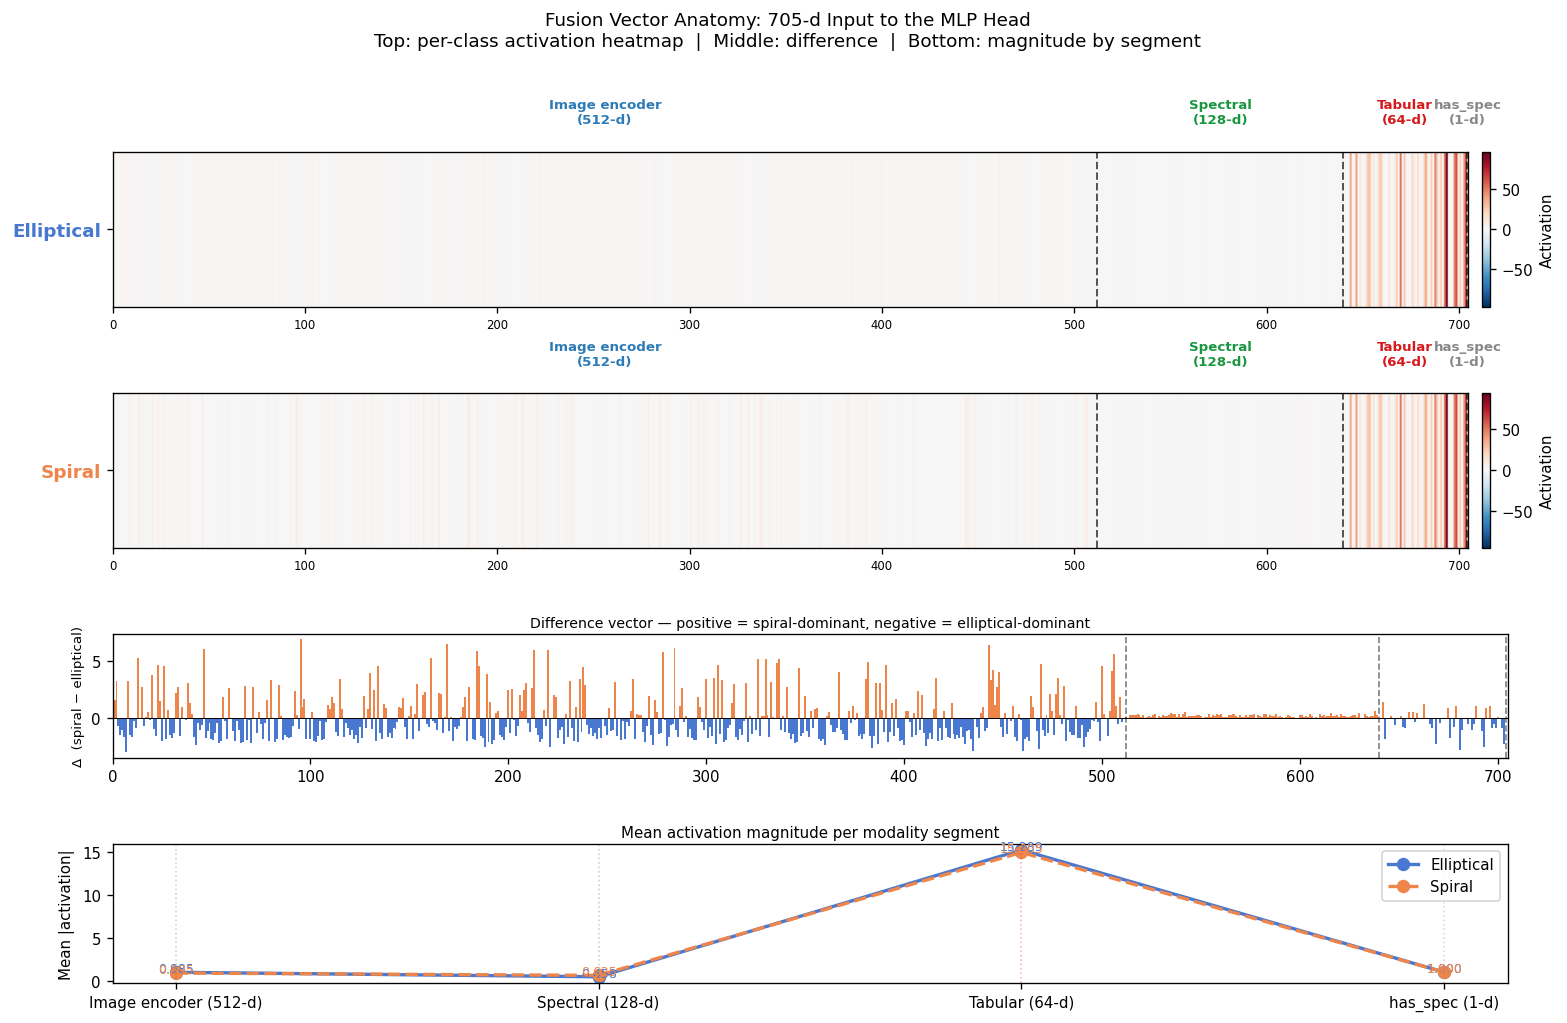

Segment mean activations:
  elliptical  : Image encoder=0.985  Spectral=0.458  Tabular=15.289  has_spec=1.000
  spiral      : Image encoder=0.895  Spectral=0.625  Tabular=15.005  has_spec=1.000


In [28]:
# 🔬 6b. Fusion vector anatomy — Spiral vs Elliptical side-by-side heatmap
# ─────────────────────────────────────────────────────────────────────────────
# Hook on the input to fusion_model.head[0] (Linear 705→256) to capture the
# full 705-d concatenated vector before the MLP head sees it.
#
# Visualisations:
#   Row 0-1: thin 1-row heatmap of the 705-d vector for each class
#   Row 2:   difference bar (spiral − elliptical) — which dims differ most?
#   Row 3:   mean |activation| per segment — how dominant is each modality?

_fused_vecs = {}
_hook = fusion_model.head[0].register_forward_hook(
    lambda m, inp, out: _fused_vecs.update({'vec': inp[0].detach().cpu().numpy()}))

_compare = ['elliptical', 'spiral']
vecs_by_class = {}

for lbl in _compare:
    row    = samples[lbl]
    img_t  = get_val_transform()(Image.open(IMG_DIR / f"{int(row['objid'])}.jpeg").convert('RGB')).unsqueeze(0).to(device)
    spec_t = torch.from_numpy(load_spectrum(spec_path(row))).unsqueeze(0).unsqueeze(0).to(device)
    tab_v  = sample_tab[lbl][feature_cols].values.astype(np.float32)
    tab_t  = torch.from_numpy(tab_v).unsqueeze(0).to(device)
    has_s  = torch.tensor([1.0]).to(device)
    with torch.no_grad():
        _ = fusion_model(img_t, spec_t, tab_t, has_s)
    vecs_by_class[lbl] = _fused_vecs['vec'][0].copy()

_hook.remove()

# Segment boundaries
SEGMENTS = [
    (0,   512, 'Image encoder\n(512-d)',   '#2c7bb6'),
    (512, 640, 'Spectral\n(128-d)',        '#1a9641'),
    (640, 704, 'Tabular\n(64-d)',          '#d7191c'),
    (704, 705, 'has_spec\n(1-d)',          '#888888'),
]

fig, axes = plt.subplots(4, 1, figsize=(15, 9),
                         gridspec_kw=dict(hspace=0.60, height_ratios=[1, 1, 0.8, 0.9]))

# ── Rows 0-1: per-class heatmaps ──────────────────────────────────────────────
for ax_i, (lbl, cls_col) in enumerate(zip(_compare, [COLORS[0], COLORS[1]])):
    ax   = axes[ax_i]
    vec  = vecs_by_class[lbl]
    vmax = max(float(np.abs(vec).max()), 0.1)

    im = ax.imshow(vec.reshape(1, -1), aspect='auto', cmap='RdBu_r',
                   vmin=-vmax, vmax=vmax, extent=[0, 705, 0, 1])
    ax.set_yticks([0.5])
    ax.set_yticklabels([lbl.capitalize()], fontsize=11, color=cls_col, fontweight='bold')
    ax.set_xlim(0, 705)
    ax.tick_params(axis='x', labelsize=7)
    plt.colorbar(im, ax=ax, fraction=0.018, pad=0.01, label='Activation')

    for x0, x1, seg_lbl, seg_c in SEGMENTS:
        if x1 < 705:
            ax.axvline(x1, color='black', lw=1.2, ls='--', alpha=0.65)
        # Label above the heatmap using axis-fraction transform
        ax.text((x0 + x1) / 2 / 705, 1.18, seg_lbl,
                ha='center', fontsize=8, color=seg_c, fontweight='bold',
                transform=ax.transAxes)

# ── Row 2: difference bar (spiral − elliptical) ───────────────────────────────
ax_d = axes[2]
diff = vecs_by_class['spiral'] - vecs_by_class['elliptical']
bar_cols = [COLORS[1] if d > 0 else COLORS[0] for d in diff]
ax_d.bar(range(705), diff, width=1.0, color=bar_cols, linewidth=0)
ax_d.axhline(0, color='black', lw=0.6)
ax_d.set_ylabel('Δ  (spiral − elliptical)', fontsize=8)
ax_d.set_xlim(0, 705)
ax_d.set_title('Difference vector — positive = spiral-dominant, negative = elliptical-dominant',
               fontsize=8.5, pad=4)
for x0, x1, _, seg_c in SEGMENTS:
    if x1 < 705:
        ax_d.axvline(x1, color='black', lw=1.0, ls='--', alpha=0.5)

# ── Row 3: mean |activation| per segment ─────────────────────────────────────
ax_m  = axes[3]
x_seg = np.arange(len(SEGMENTS))
seg_ranges = [(s[0], s[1]) for s in SEGMENTS]
seg_labels = [s[2].replace('\n', ' ') for s in SEGMENTS]
seg_cols   = [s[3] for s in SEGMENTS]

for cls_i, (lbl, ls) in enumerate(zip(_compare, ['-', '--'])):
    mags = [float(np.abs(vecs_by_class[lbl][s:e]).mean()) for s, e in seg_ranges]
    ax_m.plot(x_seg, mags, marker='o', ls=ls, lw=2.0,
              color=COLORS[cls_i], label=lbl.capitalize(), ms=7)
    for xi, mag in enumerate(mags):
        ax_m.text(xi, mag + 0.004, f'{mag:.3f}', ha='center', fontsize=7.5,
                  color=COLORS[cls_i])

ax_m.set_xticks(x_seg)
ax_m.set_xticklabels(seg_labels, fontsize=9)
ax_m.set_ylabel('Mean |activation|', fontsize=9)
ax_m.set_title('Mean activation magnitude per modality segment', fontsize=9, pad=4)
ax_m.legend(fontsize=9)
for xi, (_, _, _, sc) in enumerate(SEGMENTS):
    ax_m.axvline(xi, color=sc, lw=1.0, alpha=0.3, ls=':')

fig.suptitle('Fusion Vector Anatomy: 705-d Input to the MLP Head\n'
             'Top: per-class activation heatmap  |  Middle: difference  |  Bottom: magnitude by segment',
             fontsize=11, y=1.01)

fig.savefig(FIG_DIR / 'fig_fusion_vector.pdf', bbox_inches='tight')
fig.savefig(FIG_DIR / 'fig_fusion_vector.png', dpi=150, bbox_inches='tight')
plt.show()

print('Segment mean activations:')
for lbl in _compare:
    vec = vecs_by_class[lbl]
    parts = [f'{nm.split(chr(10))[0]}={np.abs(vec[s:e]).mean():.3f}'
             for (s, e, nm, _) in SEGMENTS]
    print(f'  {lbl:12s}: ' + '  '.join(parts))


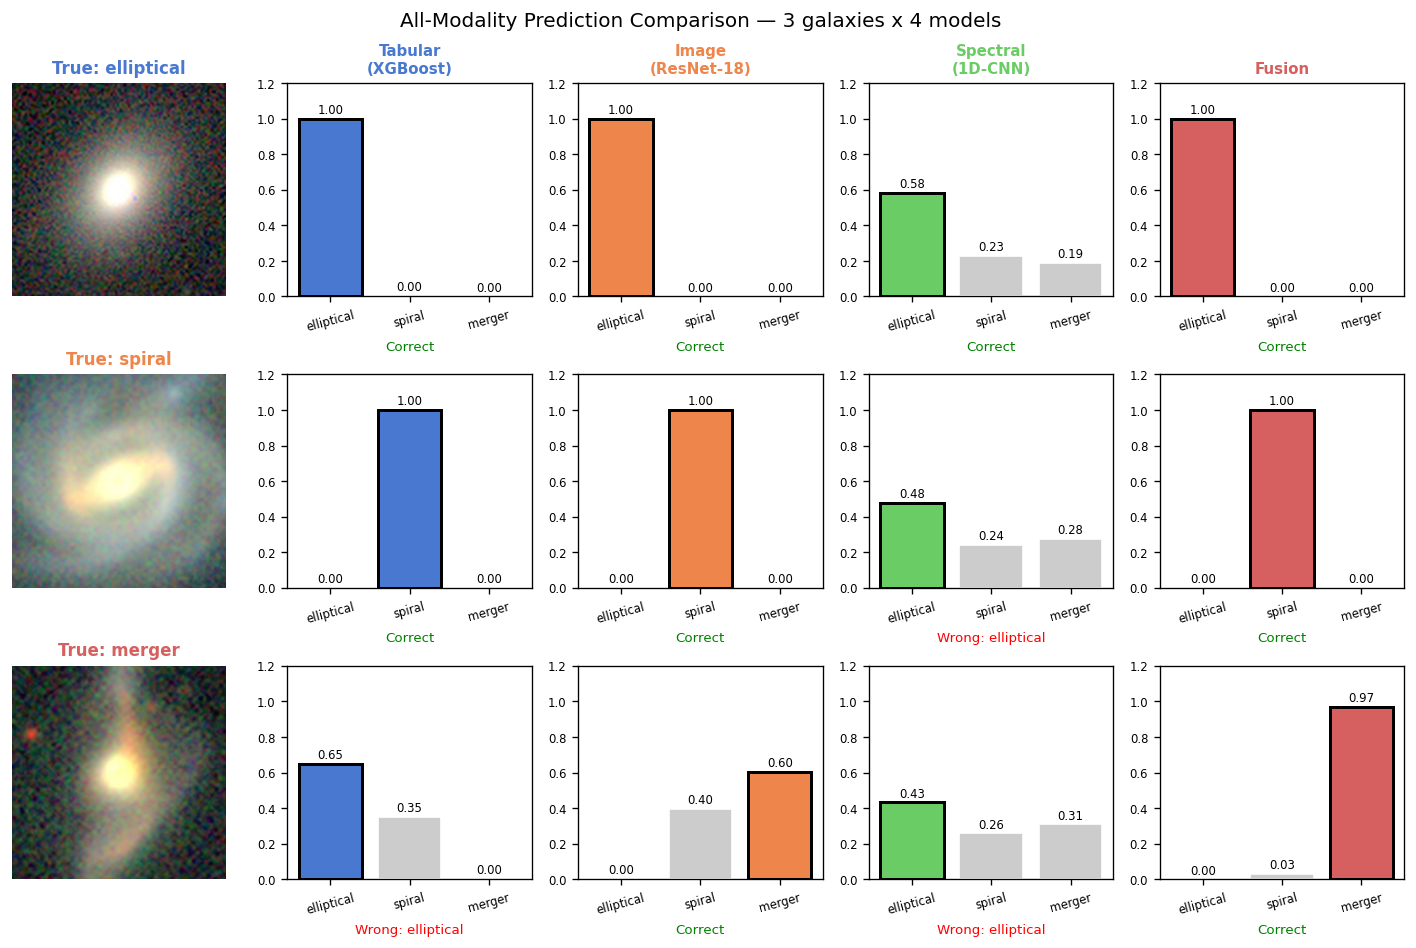

In [80]:
# ── 6c. Run fusion predictions + all-model comparison ────────────────────
fusion_results = {}
for label, row in samples.items():
    if label not in sample_tab: continue
    pil    = Image.open(IMG_DIR / f"{int(row['objid'])}.jpeg").convert('RGB')
    img_t2 = get_val_transform()(pil).unsqueeze(0).to(device)
    spec_t2 = torch.from_numpy(load_spectrum(spec_path(row))).unsqueeze(0).unsqueeze(0).to(device)
    tab_t2  = torch.from_numpy(sample_tab[label][feature_cols].values.astype(np.float32)).unsqueeze(0).to(device)
    has_s2  = torch.tensor([1.0]).to(device)
    with torch.no_grad():
        probs = F.softmax(fusion_model(img_t2, spec_t2, tab_t2, has_s2), dim=1).cpu().numpy()[0]
    fusion_results[label] = {'probs': probs, 'pred': LABEL_NAMES[probs.argmax()]}

MODEL_LABELS = ['Tabular\n(XGBoost)', 'Image\n(ResNet-18)', 'Spectral\n(1D-CNN)', 'Fusion']
MODEL_COLORS_4 = ['#4878D0', '#EE854A', '#6ACC65', '#D65F5F']

fig, axes = plt.subplots(3, 5, figsize=(12, 8))
for ri, (label, c) in enumerate(zip(LABEL_NAMES, COLORS)):
    pil = Image.open(IMG_DIR / f"{int(samples[label]['objid'])}.jpeg").convert('RGB')
    axes[ri, 0].imshow(np.array(pil.resize((224, 224))))
    axes[ri, 0].set_title(f'True: {label}', fontsize=10, fontweight='bold', color=c)
    axes[ri, 0].axis('off')

    all_res = [tab_results.get(label), img_results.get(label),
               spec_results.get(label), fusion_results.get(label)]
    for ci, (res, mc) in enumerate(zip(all_res, MODEL_COLORS_4)):
        ax = axes[ri, ci+1]
        if res is None: ax.axis('off'); continue
        bars = ax.bar(LABEL_NAMES, res['probs'], color=['#ccc']*3, edgecolor='white')
        pi = res['probs'].argmax()
        bars[pi].set_facecolor(mc); bars[pi].set_edgecolor('black'); bars[pi].set_linewidth(1.8)
        for b, v in zip(bars, res['probs']):
            ax.text(b.get_x()+b.get_width()/2, v+0.03, f'{v:.2f}', ha='center', fontsize=7)
        ax.set_ylim(0, 1.2)
        ax.tick_params(axis='x', labelsize=7, rotation=15)
        ax.tick_params(axis='y', labelsize=7)
        if ri == 0: ax.set_title(MODEL_LABELS[ci], fontsize=9, fontweight='bold', color=mc)
        ok = 'Correct' if res['pred'] == label else f'Wrong: {res["pred"]}'
        ax.set_xlabel(ok, fontsize=8, color='green' if res['pred'] == label else 'red')

fig.suptitle('All-Modality Prediction Comparison — 3 galaxies x 4 models', fontsize=12)
fig.tight_layout()
fig.savefig(FIG_DIR / 'walk_all_models_comparison.pdf', bbox_inches='tight', transparent=True)
fig.savefig(FIG_DIR / 'walk_all_models_comparison.png', dpi=200, bbox_inches='tight', transparent=True)
fig.savefig(FIG_DIR / 'walk_all_models_comparison.svg', bbox_inches='tight', transparent=True)
plt.show()

---
## Section 7 — Embedding Visualisations (t-SNE)

t-SNE projects the high-dimensional encoder outputs to 2D to show whether the model has learned class-separable representations. Well-separated clusters = the encoder has learned discriminative features.

In [30]:
# ── 7a. Extract encoder embeddings for t-SNE (balanced test sample) ──────
# Use all mergers + same count from other classes
n_merge = test_df[test_df['label'] == 'merger'].shape[0]
n_tsne  = min(n_merge, 250)
tsne_rows = []
for lb in LABEL_NAMES:
    sub = test_df[(test_df['label'] == lb) & test_df['has_image'] & test_df['has_spectrum']].head(n_tsne)
    tsne_rows.append(sub)
tsne_df = pd.concat(tsne_rows).reset_index(drop=True)
print(f't-SNE sample: {len(tsne_df)} galaxies ({n_tsne} per class)')

val_t = get_val_transform()
img_feats, spec_feats, fus_feats, true_labs = [], [], [], []

print('Extracting embeddings (may take 2-3 min on CPU)...')
for _, row in tqdm(tsne_df.iterrows(), total=len(tsne_df)):
    pil   = Image.open(IMG_DIR / f"{int(row['objid'])}.jpeg").convert('RGB')
    img_t = val_t(pil).unsqueeze(0).to(device)
    flux  = load_spectrum(spec_path(row))
    sp_t  = torch.from_numpy(flux).unsqueeze(0).unsqueeze(0).to(device)

    obj   = df_main[df_main['objid'] == int(row['objid'])]
    if len(obj) == 0:
        tab_t3 = torch.zeros(1, len(feature_cols)).to(device)
    else:
        tab_t3 = torch.from_numpy(obj.iloc[0][feature_cols].values.astype(np.float32)).unsqueeze(0).to(device)
    hs = torch.tensor([float(row['has_spectrum'])]).to(device)

    with torch.no_grad():
        f_img  = img_model.encoder(img_t)
        f_spec = spec_model.encoder(sp_t)
        f_tab  = fusion_model.tabular_encoder(tab_t3)
        fused  = torch.cat([f_img, f_spec, f_tab, hs.unsqueeze(1)], dim=1)

    img_feats.append(f_img.cpu().numpy()[0])
    spec_feats.append(f_spec.cpu().numpy()[0])
    fus_feats.append(fused.cpu().numpy()[0])
    true_labs.append(row['label'])

img_feats  = np.array(img_feats)
spec_feats = np.array(spec_feats)
fus_feats  = np.array(fus_feats)
lab_ids    = np.array([LABEL_MAP[l] for l in true_labs])
print(f'Shapes: img={img_feats.shape}  spec={spec_feats.shape}  fusion={fus_feats.shape}')

t-SNE sample: 583 galaxies (221 per class)
Extracting embeddings (may take 2-3 min on CPU)...


  0%|          | 0/583 [00:00<?, ?it/s]

Shapes: img=(583, 512)  spec=(583, 128)  fusion=(583, 705)


Computing t-SNE for 3 embedding spaces...
Done.


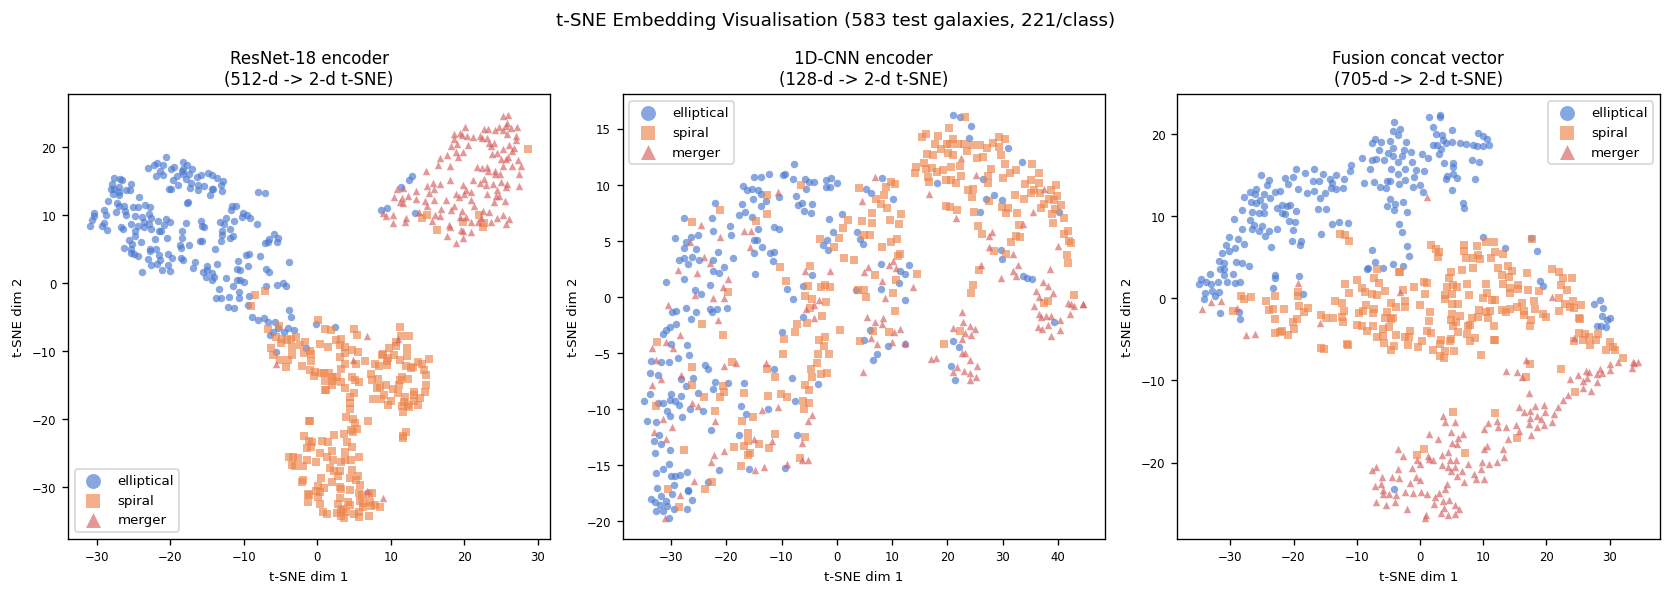

In [31]:
# ── 7b. t-SNE computation and plot ────────────────────────────────────────
print('Computing t-SNE for 3 embedding spaces...')
tsne_img  = TSNE(n_components=2, perplexity=30, random_state=42).fit_transform(img_feats)
tsne_spec = TSNE(n_components=2, perplexity=30, random_state=42).fit_transform(spec_feats)
tsne_fus  = TSNE(n_components=2, perplexity=30, random_state=42).fit_transform(fus_feats)
print('Done.')

fig, axes = plt.subplots(1, 3, figsize=(14, 5))
markers   = ['o', 's', '^']
for ax, (emb, title) in zip(axes, [
    (tsne_img,  f'ResNet-18 encoder\n(512-d -> 2-d t-SNE)'),
    (tsne_spec, f'1D-CNN encoder\n(128-d -> 2-d t-SNE)'),
    (tsne_fus,  f'Fusion concat vector\n(705-d -> 2-d t-SNE)'),
]):
    for idx, (lb, c, m) in enumerate(zip(LABEL_NAMES, COLORS, markers)):
        mask = lab_ids == idx
        ax.scatter(emb[mask, 0], emb[mask, 1],
                   c=c, label=lb, alpha=0.65, s=20, marker=m, linewidths=0)
    ax.set_title(title, fontsize=10)
    ax.set_xlabel('t-SNE dim 1', fontsize=8); ax.set_ylabel('t-SNE dim 2', fontsize=8)
    ax.legend(fontsize=8, markerscale=2)
    ax.tick_params(labelsize=7)

fig.suptitle(f't-SNE Embedding Visualisation ({len(tsne_df)} test galaxies, {n_tsne}/class)', fontsize=11)
fig.tight_layout()
fig.savefig(FIG_DIR / 'fig_tsne_embeddings.pdf', bbox_inches='tight')
fig.savefig(FIG_DIR / 'fig_tsne_embeddings.png', dpi=200, bbox_inches='tight')
plt.show()

---
## Section 8 — Performance, Hyperparameter Search & Interpretability

In [32]:
# ── 8a. Summary results table ─────────────────────────────────────────────
results = {
    'Tabular (XGBoost)':   load_pkl('../checkpoints/tabular/test_results_full.pkl'),
    'Image (ResNet-18 C)': load_pkl('../checkpoints/image/test_results_configC.pkl'),
    'Spectral (1D-CNN)':   load_pkl('../checkpoints/spectral/test_results.pkl'),
    'Fusion (best enc.)':  load_pkl('../checkpoints/fusion/test_results_bestenc.pkl'),
}

rows = []
for name, r in results.items():
    row = {'Model': name, 'Macro F1': round(r['macro_f1'], 4),
           'Weighted F1': round(r['weighted_f1'], 4), 'Accuracy': round(r['accuracy'], 4)}
    for cls in LABEL_NAMES:
        row[f'{cls[:4].capitalize()} F1'] = round(r['per_class'].get(cls, {}).get('f1-score', 0), 3)
    rows.append(row)

df_perf = pd.DataFrame(rows).set_index('Model')
display(df_perf)

,Macro F1,Weighted F1,Accuracy,Elli F1,Spir F1,Merg F1
Model,,,,,,
Tabular (XGBoost),0.7751,0.9398,0.9399,0.944,0.942,0.439
Image (ResNet-18 C),0.8073,0.9575,0.9548,0.963,0.958,0.501
Spectral (1D-CNN),0.5627,0.7807,0.7773,0.770,0.800,0.118
Fusion (best enc.),0.8728,0.9679,0.9672,0.972,0.968,0.679


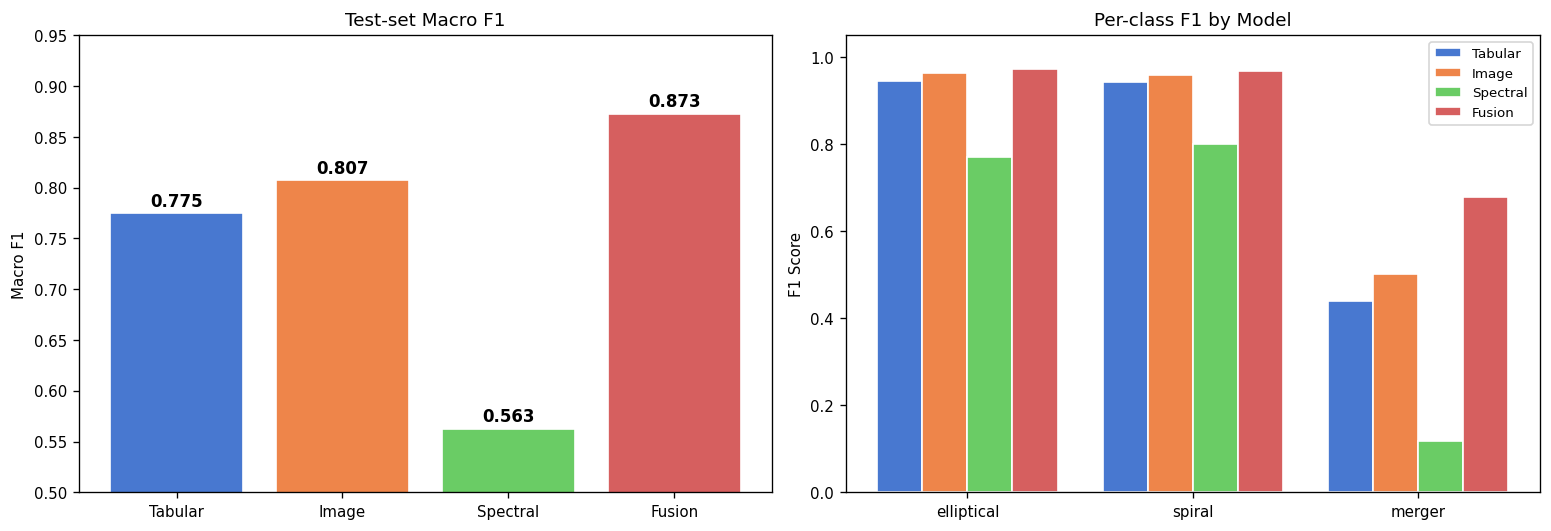

In [33]:
# ── 8b. Macro F1 + per-class F1 bar charts ───────────────────────────────
model_names  = list(results.keys())
short_names  = ['Tabular', 'Image', 'Spectral', 'Fusion']
mc = ['#4878D0', '#EE854A', '#6ACC65', '#D65F5F']

fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

# Macro F1
f1s = [r['macro_f1'] for r in results.values()]
bars = axes[0].bar(short_names, f1s, color=mc, edgecolor='white')
for b, v in zip(bars, f1s):
    axes[0].text(b.get_x()+b.get_width()/2, v+0.003, f'{v:.3f}', ha='center', va='bottom', fontsize=10, fontweight='bold')
axes[0].set_ylim(0.5, 0.95)
axes[0].set_ylabel('Macro F1')
axes[0].set_title('Test-set Macro F1', fontsize=11)

# Per-class F1
x = np.arange(3); w = 0.2
for i, (sn, mc_i, r) in enumerate(zip(short_names, mc, results.values())):
    vals = [r['per_class'].get(c, {}).get('f1-score', 0) for c in LABEL_NAMES]
    axes[1].bar(x + (i-1.5)*w, vals, w, label=sn, color=mc_i, edgecolor='white')
axes[1].set_xticks(x); axes[1].set_xticklabels(LABEL_NAMES)
axes[1].set_ylabel('F1 Score')
axes[1].set_title('Per-class F1 by Model', fontsize=11)
axes[1].legend(fontsize=8); axes[1].set_ylim(0, 1.05)

fig.tight_layout()
fig.savefig(FIG_DIR / 'fig1_macro_f1.pdf', bbox_inches='tight')
fig.savefig(FIG_DIR / 'fig1_macro_f1.png', dpi=200, bbox_inches='tight')
plt.show()

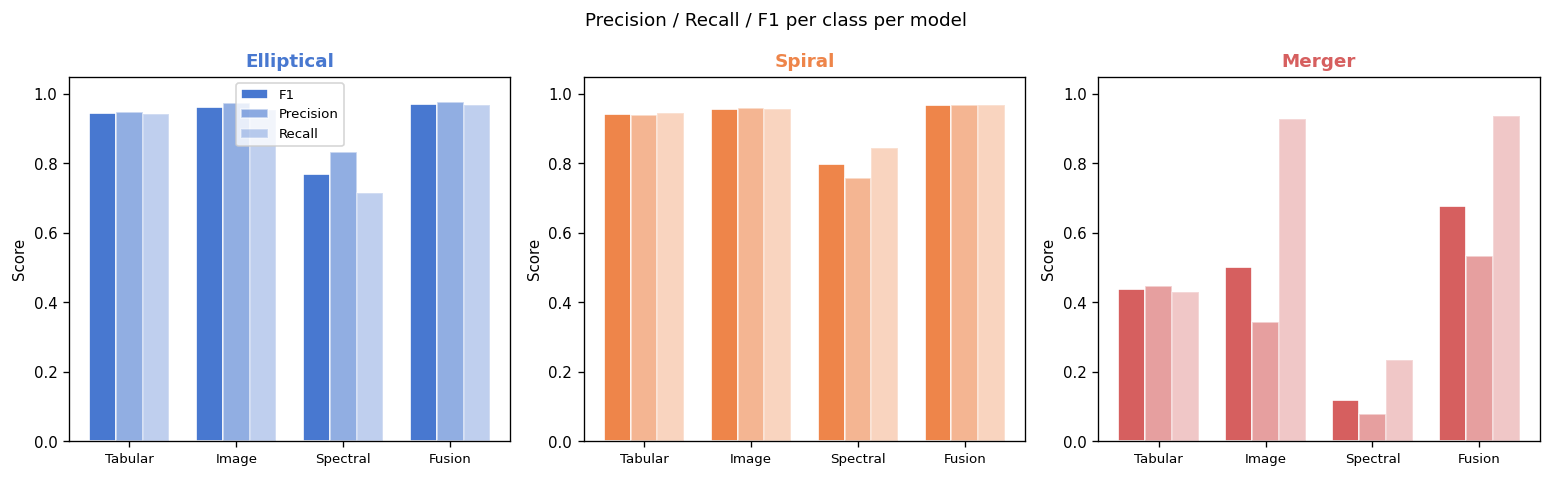

In [34]:
# ── 8c. Per-class F1 breakdown chart ─────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(13, 4))
for ax, cls, c in zip(axes, LABEL_NAMES, COLORS):
    vals = [r['per_class'].get(cls, {}).get('f1-score', 0) for r in results.values()]
    prec = [r['per_class'].get(cls, {}).get('precision', 0) for r in results.values()]
    rec  = [r['per_class'].get(cls, {}).get('recall', 0) for r in results.values()]
    x    = np.arange(4)
    ax.bar(x-0.25, vals, 0.25, label='F1',       color=c,    edgecolor='white')
    ax.bar(x,      prec, 0.25, label='Precision', color=c,    edgecolor='white', alpha=0.6)
    ax.bar(x+0.25, rec,  0.25, label='Recall',    color=c,    edgecolor='white', alpha=0.35)
    ax.set_xticks(x); ax.set_xticklabels(short_names, fontsize=8)
    ax.set_ylim(0, 1.05); ax.set_ylabel('Score'); ax.set_title(f'{cls.capitalize()}', fontsize=11, color=c, fontweight='bold')
    if ax == axes[0]: ax.legend(fontsize=8)
fig.suptitle('Precision / Recall / F1 per class per model', fontsize=11)
fig.tight_layout()
fig.savefig(FIG_DIR / 'fig2_perclass_f1.pdf', bbox_inches='tight')
fig.savefig(FIG_DIR / 'fig2_perclass_f1.png', dpi=200, bbox_inches='tight')
plt.show()

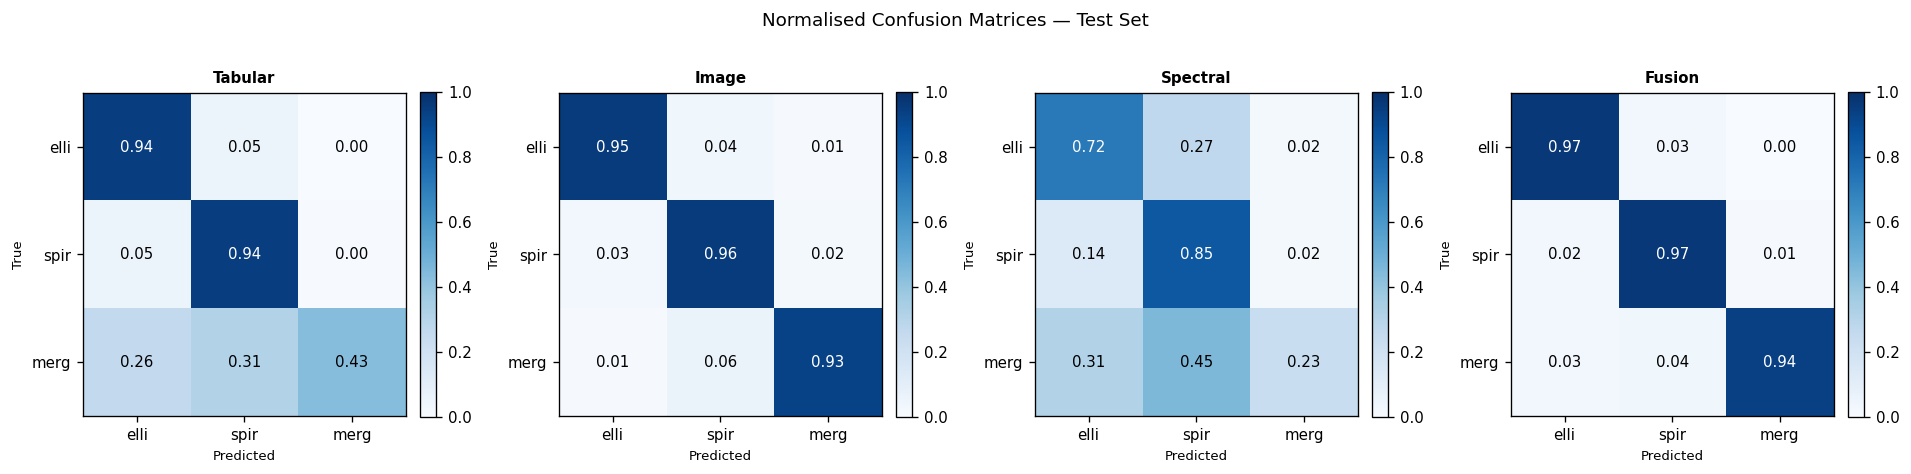

In [81]:
# ── 8d. Normalised confusion matrices ─────────────────────────────────────
fig, axes = plt.subplots(1, 4, figsize=(16, 4))
for ax, (name, r), mc_i in zip(axes, results.items(), mc):
    cm   = np.array(r['confusion_matrix'])
    cm_n = cm.astype(float) / cm.sum(axis=1, keepdims=True)
    im   = ax.imshow(cm_n, cmap='Blues', vmin=0, vmax=1)
    ax.set_xticks(range(3)); ax.set_xticklabels([lb[:4] for lb in LABEL_NAMES], fontsize=9)
    ax.set_yticks(range(3)); ax.set_yticklabels([lb[:4] for lb in LABEL_NAMES], fontsize=9)
    ax.set_xlabel('Predicted', fontsize=8); ax.set_ylabel('True', fontsize=8)
    ax.set_title(name.split('(')[0].strip(), fontsize=9, fontweight='bold')
    for i in range(3):
        for j in range(3):
            ax.text(j, i, f'{cm_n[i,j]:.2f}', ha='center', va='center', fontsize=9,
                    color='white' if cm_n[i,j] > 0.5 else 'black')
    plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
fig.suptitle('Normalised Confusion Matrices — Test Set', fontsize=11)
fig.tight_layout()
fig.savefig(FIG_DIR / 'fig3_confusion_matrices.pdf', bbox_inches='tight', transparent=True)
fig.savefig(FIG_DIR / 'fig3_confusion_matrices.png', dpi=200, bbox_inches='tight', transparent=True)
fig.savefig(FIG_DIR / 'fig3_confusion_matrices.svg', bbox_inches='tight', transparent=True)
plt.show()

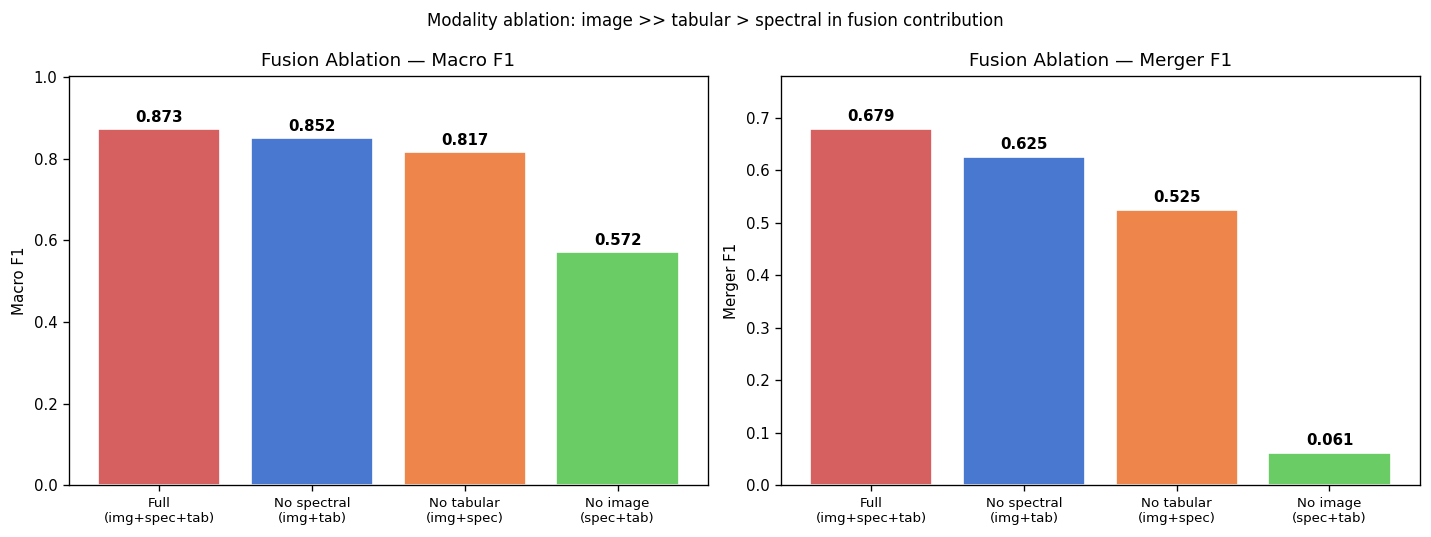

In [82]:
# ── 8e. Fusion ablation study ─────────────────────────────────────────────
abl_data = {
    'Full\n(img+spec+tab)':  load_pkl('../checkpoints/fusion/test_results_bestenc.pkl'),
    'No spectral\n(img+tab)': load_pkl('../checkpoints/fusion/test_results_ablate_nospec.pkl'),
    'No tabular\n(img+spec)': load_pkl('../checkpoints/fusion/test_results_ablate_notab.pkl'),
    'No image\n(spec+tab)':   load_pkl('../checkpoints/fusion/test_results_ablate_noimg.pkl'),
}
abl_names  = list(abl_data.keys())
abl_colors = ['#D65F5F', '#4878D0', '#EE854A', '#6ACC65']

fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))
for ax, (metric, title, ylabel) in zip(axes, [
    ('macro_f1',   'Fusion Ablation — Macro F1',   'Macro F1'),
    ('merger_f1',  'Fusion Ablation — Merger F1',  'Merger F1'),
]):
    if metric == 'macro_f1':
        vals = [abl_data[n]['macro_f1'] for n in abl_names]
    else:
        vals = [abl_data[n]['per_class'].get('merger', {}).get('f1-score', 0) for n in abl_names]
    bars = ax.bar(abl_names, vals, color=abl_colors, edgecolor='white')
    for b, v in zip(bars, vals):
        ax.text(b.get_x()+b.get_width()/2, v+0.01, f'{v:.3f}', ha='center', va='bottom', fontsize=9, fontweight='bold')
    ax.set_ylim(0, max(vals)*1.15)
    ax.set_ylabel(ylabel); ax.set_title(title, fontsize=11)
    ax.tick_params(axis='x', labelsize=8)

fig.suptitle('Modality ablation: image >> tabular > spectral in fusion contribution', fontsize=10)
fig.tight_layout()
fig.savefig(FIG_DIR / 'fig5_ablation.pdf', bbox_inches='tight', transparent=True)
fig.savefig(FIG_DIR / 'fig5_ablation.png', dpi=200, bbox_inches='tight', transparent=True)
fig.savefig(FIG_DIR / 'fig5_ablation.svg', bbox_inches='tight', transparent=True)
plt.show()

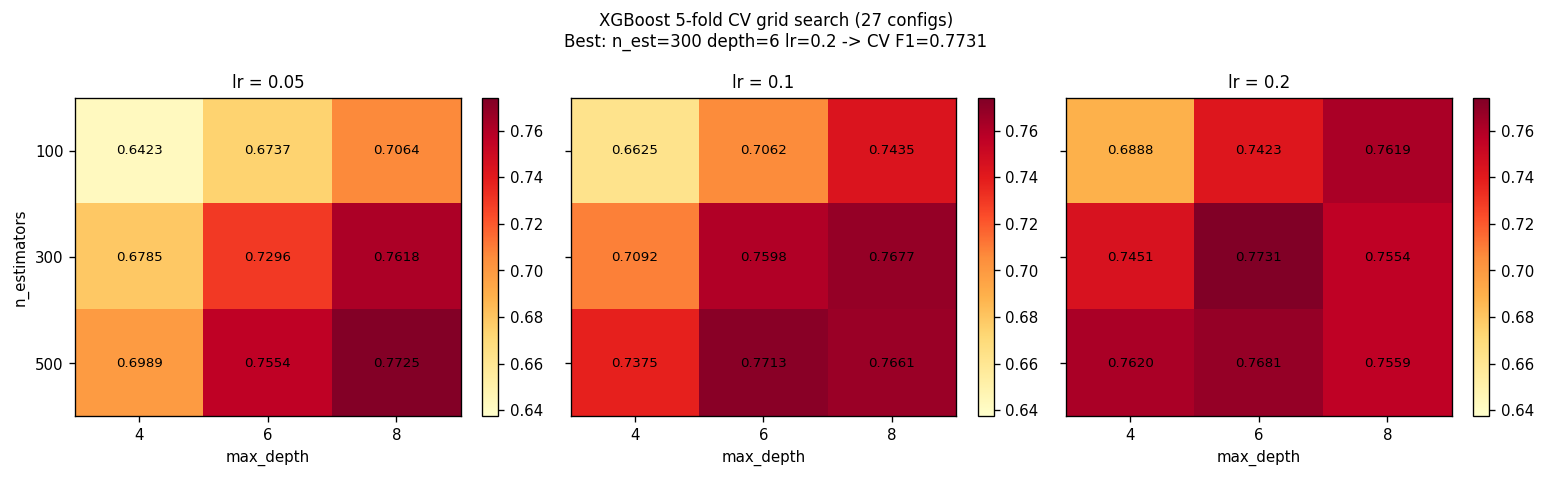

In [41]:
# ── 8f. XGBoost hyperparameter grid search (3D heatmap) ──────────────────
gs = pd.read_csv('../checkpoints/tabular/grid_search_results.csv')
lrs = sorted(gs['learning_rate'].unique())

fig, axes = plt.subplots(1, 3, figsize=(13, 4), sharey=True)
for ax, lr in zip(axes, lrs):
    sub = gs[gs['learning_rate'] == lr].pivot(index='n_estimators', columns='max_depth', values='cv_macro_f1')
    im  = ax.imshow(sub.values, cmap='YlOrRd', aspect='auto',
                    vmin=gs['cv_macro_f1'].min() - 0.005, vmax=gs['cv_macro_f1'].max() + 0.001)
    ax.set_xticks(range(len(sub.columns))); ax.set_xticklabels(sub.columns)
    ax.set_yticks(range(len(sub.index)));   ax.set_yticklabels(sub.index)
    ax.set_xlabel('max_depth'); ax.set_ylabel('n_estimators') if lr == lrs[0] else None
    ax.set_title(f'lr = {lr}', fontsize=10)
    for i in range(len(sub.index)):
        for j in range(len(sub.columns)):
            ax.text(j, i, f'{sub.values[i,j]:.4f}', ha='center', va='center', fontsize=8)
    plt.colorbar(im, ax=ax, fraction=0.05)

best = gs.iloc[0]
fig.suptitle(f'XGBoost 5-fold CV grid search (27 configs)\n'
             f'Best: n_est={best["n_estimators"]:.0f} depth={best["max_depth"]:.0f} '
             f'lr={best["learning_rate"]} -> CV F1={best["cv_macro_f1"]:.4f}', fontsize=10)
fig.tight_layout()
fig.savefig(FIG_DIR / 'fig4_hyperparam_search.pdf', bbox_inches='tight', transparent=True)
fig.savefig(FIG_DIR / 'fig4_hyperparam_search.png', dpi=200, bbox_inches='tight', transparent=True)
plt.show()

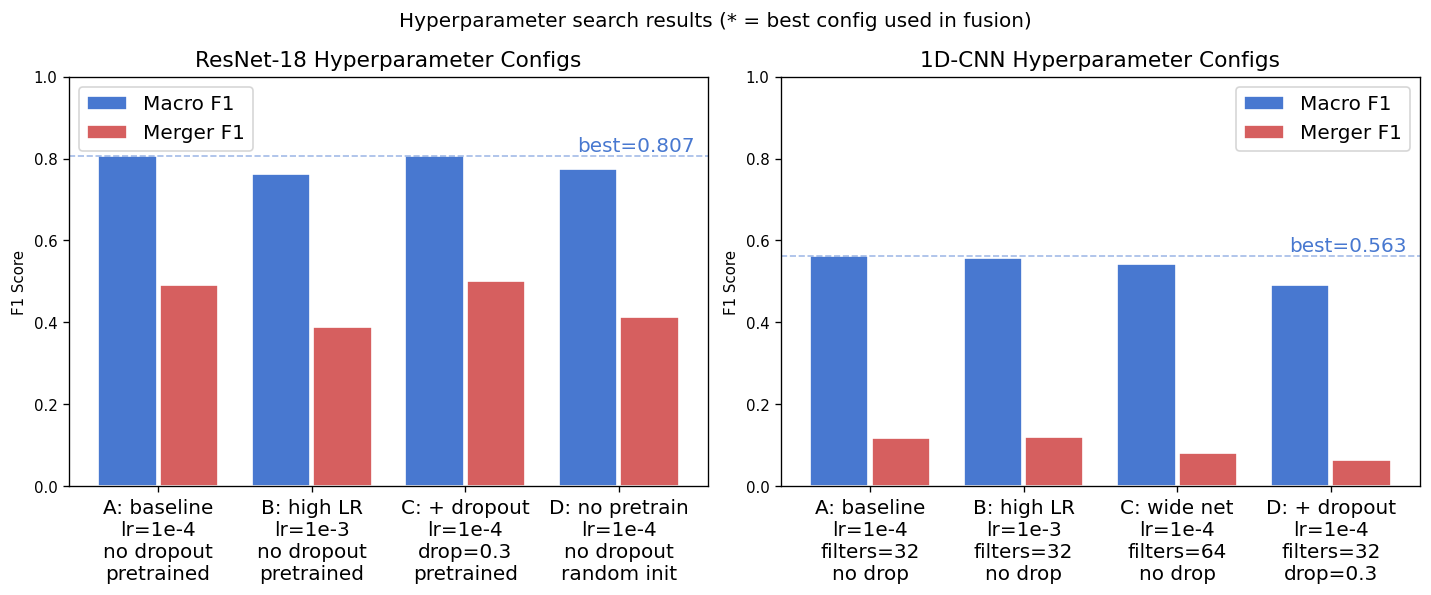

In [67]:
# ── 8g. Image config comparison ──────────────────────────────────────────
img_configs = {
    'A: baseline\nlr=1e-4\nno dropout\npretrained':     load_pkl('../checkpoints/image/test_results.pkl'),
    'B: high LR\nlr=1e-3\nno dropout\npretrained':      load_pkl('../checkpoints/image/test_results_configB.pkl'),
    'C: + dropout\nlr=1e-4\ndrop=0.3\npretrained':     load_pkl('../checkpoints/image/test_results_configC.pkl'),
    'D: no pretrain\nlr=1e-4\nno dropout\nrandom init': load_pkl('../checkpoints/image/test_results_configD.pkl'),
}
spec_configs = {
    'A: baseline\nlr=1e-4\nfilters=32\nno drop':  load_pkl('../checkpoints/spectral/test_results.pkl'),
    'B: high LR\nlr=1e-3\nfilters=32\nno drop':   load_pkl('../checkpoints/spectral/test_results_configB.pkl'),
    'C: wide net\nlr=1e-4\nfilters=64\nno drop':  load_pkl('../checkpoints/spectral/test_results_configC.pkl'),
    'D: + dropout\nlr=1e-4\nfilters=32\ndrop=0.3':load_pkl('../checkpoints/spectral/test_results_configD.pkl'),
}

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
for ax, (title, cfgs) in zip(axes, [
    ('ResNet-18 Hyperparameter Configs', img_configs),
    ('1D-CNN Hyperparameter Configs', spec_configs),
]):
    names = list(cfgs.keys())
    f1s   = [r['macro_f1'] for r in cfgs.values()]
    mer   = [r['per_class'].get('merger', {}).get('f1-score', 0) for r in cfgs.values()]
    x     = np.arange(len(names))
    ax.bar(x - 0.2, f1s, 0.38, label='Macro F1',  color='#4878D0', edgecolor='white')
    ax.bar(x + 0.2, mer, 0.38, label='Merger F1', color='#D65F5F', edgecolor='white')
    ax.set_xticks(x); ax.set_xticklabels(names, fontsize=12)
    ax.set_ylim(0, 1.0); ax.set_ylabel('F1 Score')
    ax.set_title(title, fontsize=13)
    ax.legend(fontsize=12)
    ax.axhline(max(f1s), color='#4878D0', lw=1, ls='--', alpha=0.5)
    ax.text(0.98, max(f1s)+0.01, f'best={max(f1s):.3f}', ha='right', transform=ax.transAxes,
            fontsize=12, color='#4878D0')

fig.suptitle('Hyperparameter search results (* = best config used in fusion)', fontsize=12)
fig.tight_layout()
fig.savefig(FIG_DIR / 'fig_hyperparam_configs.pdf', bbox_inches='tight', transparent=True)
fig.savefig(FIG_DIR / 'fig_hyperparam_configs.png', dpi=150, bbox_inches='tight', transparent=True)
fig.savefig(FIG_DIR / 'fig_hyperparam_configs.svg', bbox_inches='tight', transparent=True)
fig.savefig
plt.show()

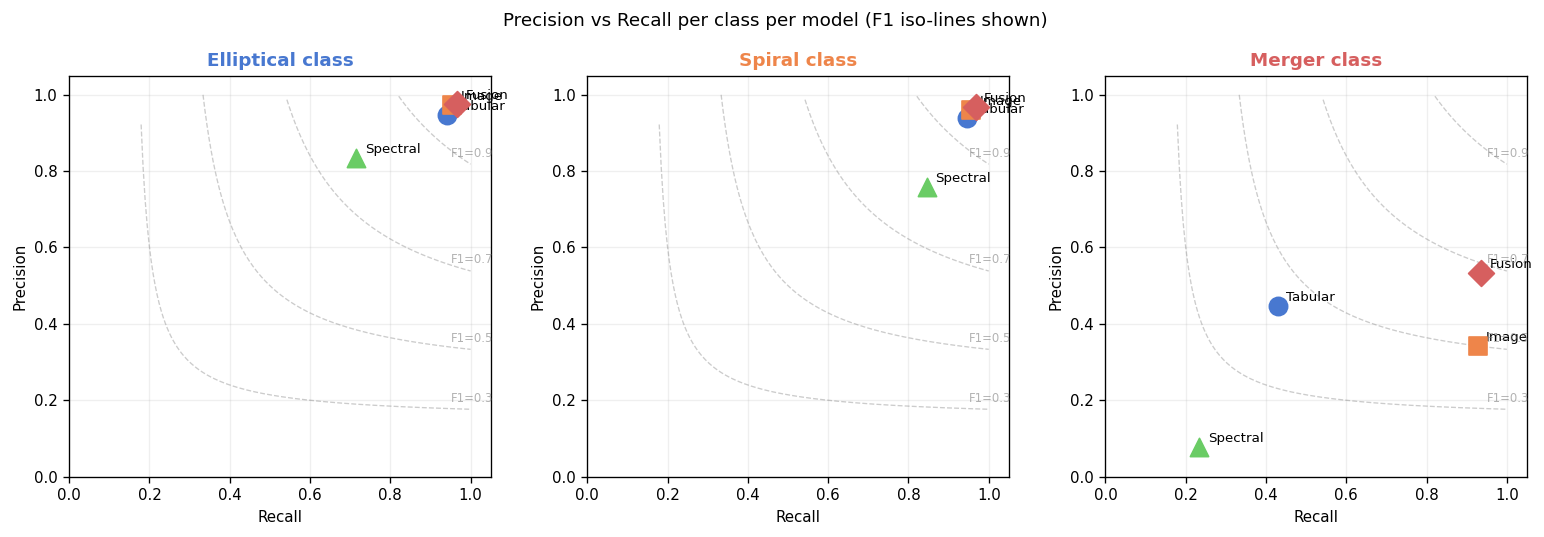

In [39]:
# ── 8h. Precision-recall scatter per class per model ─────────────────────
fig, axes = plt.subplots(1, 3, figsize=(13, 4.5))
for ax, cls, c in zip(axes, LABEL_NAMES, COLORS):
    for i, (sn, r, mc_i) in enumerate(zip(short_names, results.values(), mc)):
        pc  = r['per_class'].get(cls, {})
        prec, rec, f1v = pc.get('precision', 0), pc.get('recall', 0), pc.get('f1-score', 0)
        ax.scatter(rec, prec, color=mc_i, s=120, zorder=5, marker=['o','s','^','D'][i])
        ax.annotate(sn, (rec, prec), textcoords='offset points', xytext=(5, 3), fontsize=8)

    # F1 iso-lines
    for iso_f1 in [0.3, 0.5, 0.7, 0.9]:
        rec_pts = np.linspace(0.01, 1.0, 200)
        prec_pts = iso_f1 * rec_pts / (2*rec_pts - iso_f1)
        mask = (prec_pts >= 0) & (prec_pts <= 1)
        ax.plot(rec_pts[mask], prec_pts[mask], '--', color='gray', lw=0.8, alpha=0.4)
        ax.text(rec_pts[mask][-1]-0.05, prec_pts[mask][-1]+0.02, f'F1={iso_f1}',
                fontsize=7, color='gray', alpha=0.6)

    ax.set_xlim(0, 1.05); ax.set_ylim(0, 1.05)
    ax.set_xlabel('Recall', fontsize=9); ax.set_ylabel('Precision', fontsize=9)
    ax.set_title(f'{cls.capitalize()} class', fontsize=11, color=c, fontweight='bold')
    ax.grid(True, alpha=0.2)

fig.suptitle('Precision vs Recall per class per model (F1 iso-lines shown)', fontsize=11)
fig.tight_layout()
fig.savefig(FIG_DIR / 'fig_precision_recall.pdf', bbox_inches='tight')
fig.savefig(FIG_DIR / 'fig_precision_recall.png', dpi=150, bbox_inches='tight')
plt.show()

In [40]:
# ── 8j. Figure inventory: all saved files ─────────────────────────────────
figs = sorted(FIG_DIR.glob('*.pdf')) + sorted(FIG_DIR.glob('*.png'))
print(f'All figures saved to {FIG_DIR}/ ({len(figs)} files):')
for f in sorted(FIG_DIR.glob('*.pdf')):
    print(f'  {f.name}')

All figures saved to figures/ (72 files):
  fig0_sample_galaxies.pdf
  fig10_confidence_trust.pdf
  fig11_failure_modes.pdf
  fig12_redshift_magnitude_breakdown.pdf
  fig1_macro_f1.pdf
  fig1b_class_distribution.pdf
  fig2_perclass_f1.pdf
  fig3_confusion_matrices.pdf
  fig4_hyperparam_search.pdf
  fig5_ablation.pdf
  fig6_feature_importance.pdf
  fig7_gradcam.pdf
  fig8_physical.pdf
  fig9_spectral_cost_benefit.pdf
  fig_cnn_training_curves.pdf
  fig_feature_distributions.pdf
  fig_fusion_vector.pdf
  fig_hyperparam_configs.pdf
  fig_precision_recall.pdf
  fig_spec_layer_activations.pdf
  fig_tsne_embeddings.pdf
  fig_xgb_training_curve.pdf
  walk_ablation.pdf
  walk_all_models_comparison.pdf
  walk_confidence_evolution.pdf
  walk_confusion.pdf
  walk_feature_importance.pdf
  walk_fusion_arch.pdf
  walk_img_features.pdf
  walk_img_predictions.pdf
  walk_img_transforms.pdf
  walk_performance.pdf
  walk_raw_images.pdf
  walk_resnet_feature_maps.pdf
  walk_spec_predictions.pdf
  walk_spe